# IF3270 Pembelajaran Mesin - Tugas Besar 1
Kelompok: 56
Anggota:
- Andi Farhan Hidayat 13523128
- Andri Nurdianto 13523145
- Rafael Marchel Darma W 13523146

## Import Libraries

In [15]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

from ffnn import FFNN
from loss import MSE, BCE, CCE
from activation import Linear, ReLU, Sigmoid, HyperbolicTangent, Softmax

In [16]:
df = pd.read_csv("../datasetml_2026.csv")

## EDA

In [17]:
df.describe()

,cgpa,backlogs,internship_count,aptitude_score,communication_score,internship_quality_score
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,6.998290,1.248100,1.49930,69.877531,65.158600,5.021436
std,0.802606,1.149904,1.20289,14.700532,14.740446,1.505975
min,4.000000,0.000000,0.00000,30.000000,30.000000,1.000000
25%,6.461928,0.000000,1.00000,59.880399,55.112244,4.012656
50%,6.997924,1.000000,1.00000,70.097368,65.006484,5.017335
75%,7.536865,2.000000,2.00000,80.213934,75.277248,6.031400
max,10.000000,6.000000,5.00000,100.000000,100.000000,10.000000


In [18]:
df.isna().sum()

cgpa                        0
backlogs                    0
college_tier                0
country                     0
university_ranking_band     0
internship_count            0
aptitude_score              0
communication_score         0
specialization              0
industry                    0
internship_quality_score    0
placement_status            0
dtype: int64

In [19]:
df.dtypes

cgpa                        float64
backlogs                      int64
college_tier                    str
country                         str
university_ranking_band         str
internship_count              int64
aptitude_score              float64
communication_score         float64
specialization                  str
industry                        str
internship_quality_score    float64
placement_status                str
dtype: object

In [20]:
print(df.shape)
print(df.head(10))

(10000, 12)
       cgpa  backlogs college_tier  country university_ranking_band  \
0  7.397371         1       Tier 2   Canada                 100-300   
1  6.889389         0       Tier 3       UK                    300+   
2  7.518151         0       Tier 1       UK                 100-300   
3  8.218424         0       Tier 2       UK                 100-300   
4  6.812677         1       Tier 2      USA                 100-300   
5  6.812690         0       Tier 1  Germany                    300+   
6  8.263370         1       Tier 3    India                    300+   
7  7.613948         2       Tier 3   Canada                    300+   
8  6.624420         0       Tier 2    India                 100-300   
9  7.434048         3       Tier 3  Germany                 Top 100   

   internship_count  aptitude_score  communication_score specialization  \
0                 2       53.574150            64.177062   Data Science   
1                 1       60.687750            88.346052

In [21]:
df.nunique()

cgpa                        9998
backlogs                       7
college_tier                   3
country                        5
university_ranking_band        3
internship_count               6
aptitude_score              9720
communication_score         9835
specialization                 5
industry                       6
internship_quality_score    9961
placement_status               2
dtype: int64

In [22]:
df['placement_status'].value_counts()

placement_status
Placed        6153
Not Placed    3847
Name: count, dtype: int64

In [23]:
numeric_col = [
    "cgpa",
    "backlogs",
    "internship_count",
    "aptitude_score",
    "communication_score",
    "internship_quality_score"
]

categorical_cols = [
    "college tier",
    "country",
    "university_ranking_band",
    "specialization",
    "industry",
    "placement_status"
]

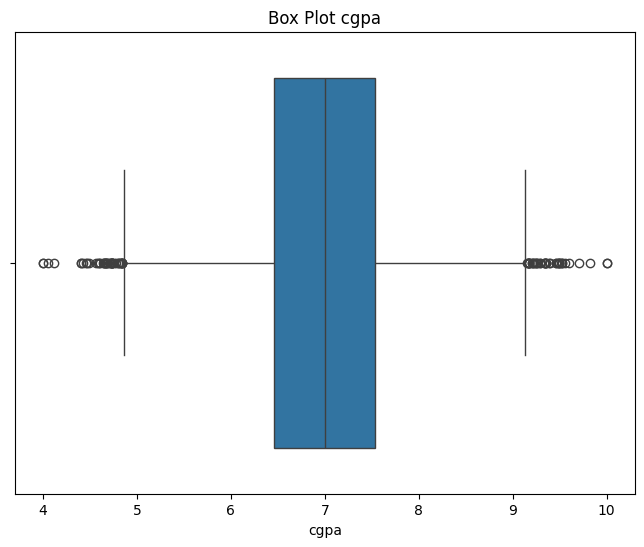

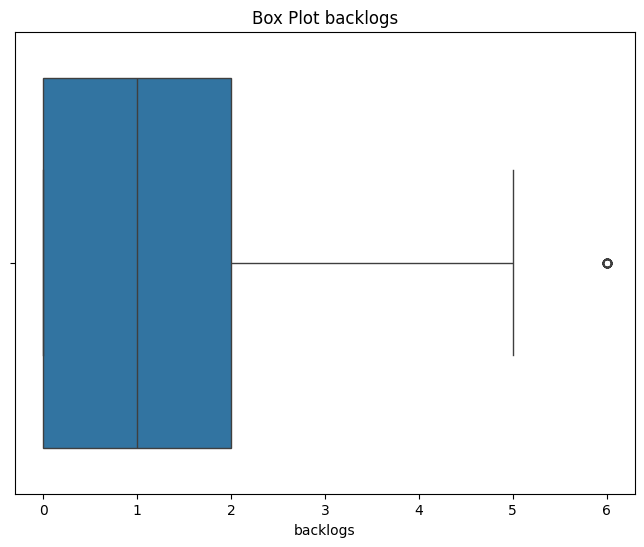

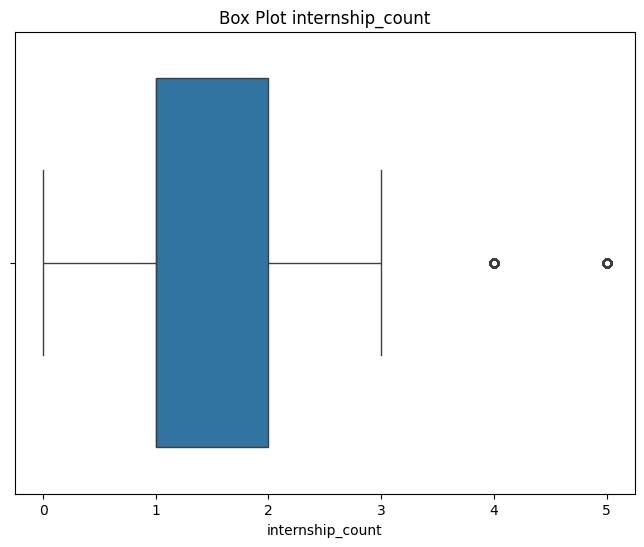

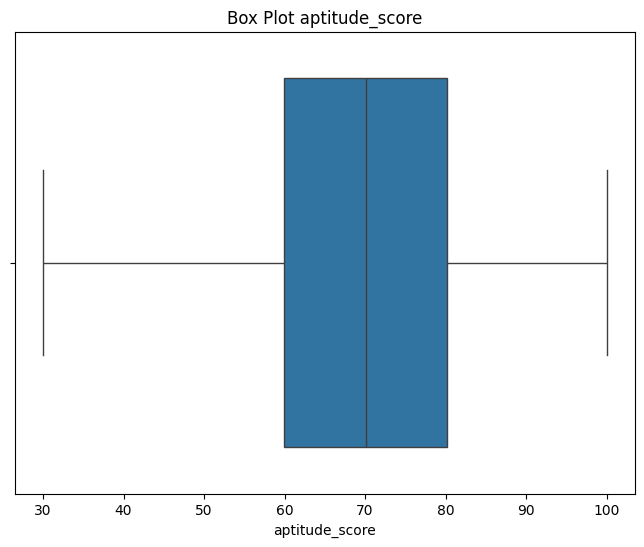

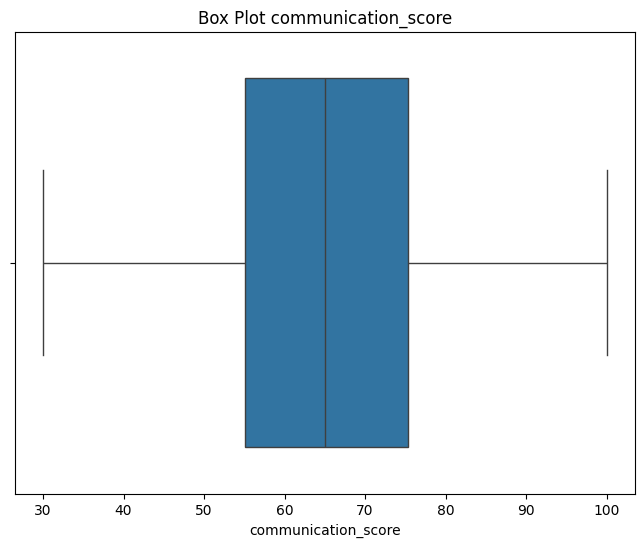

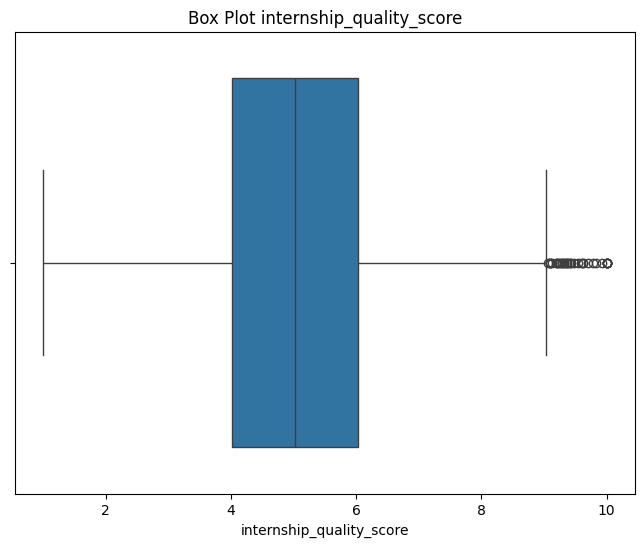

In [24]:
for col in numeric_col:
    plt.figure(figsize=(8,6))
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot {col}')
    plt.show

In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
# University ranking encoding
univ_rank = {"Top 100": 1, "100-300": 2, "300+": 3}
df["university_ranking_band"] = df["university_ranking_band"].map(univ_rank)

# Placement status encoding
placement_encode = {"Not Placed": 0, "Placed": 1}
df["placement_status"] = df["placement_status"].map(placement_encode)

In [27]:
X = df.drop("placement_status", axis=1)
y = df["placement_status"]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

### Persiapan Data (Encoding, Scaling & Reshape)

In [28]:
# One-Hot Encoding
categorical_cols = X_train.select_dtypes(include=['object', 'string']).columns
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True, dtype=float)
X_val_encoded = pd.get_dummies(X_val, columns=categorical_cols, drop_first=True, dtype=float)

# Reshape for Missing
X_train_encoded, X_val_encoded = X_train_encoded.align(X_val_encoded, join='left', axis=1, fill_value=0.0)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_val_scaled = scaler.transform(X_val_encoded)

y_train_np = y_train.values.reshape(-1, 1)
y_val_np = y_val.values.reshape(-1, 1)

input_dim = X_train_scaled.shape[1]
output_dim = 1


### Utility Functions
Fungsi bantuan untuk plot grafik history dari pelatihan FFNN.

In [29]:
def plot_history(history, title="Training vs Validation Loss"):
    plt.figure(figsize=(8,5))
    plt.plot(history['train_loss'], label='Train Loss')
    if len(history['val_loss']) > 0 and history['val_loss'][0] is not None:
        plt.plot(history['val_loss'], label='Validation Loss')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

def calculate_accuracy(y_true, y_pred):
    y_pred_class = (y_pred >= 0.5).astype(int)
    return np.mean(y_true == y_pred_class)


## Pengujian

### 1. Pengaruh Depth dan Width
#### 1.a. Variasi Width dengan Depth = 3 (Input, Hidden, Output)


Melatih FFNN dengan 1 hidden layer (width=16)...
Epoch 1/20 [==============================] 100% - loss: 0.6987 - val_loss: 0.6864
Epoch 2/20 [==============================] 100% - loss: 0.6812 - val_loss: 0.6712
Epoch 3/20 [==============================] 100% - loss: 0.6665 - val_loss: 0.6585
Epoch 4/20 [==============================] 100% - loss: 0.6541 - val_loss: 0.6478
Epoch 5/20 [==============================] 100% - loss: 0.6435 - val_loss: 0.6387
Epoch 6/20 [==============================] 100% - loss: 0.6345 - val_loss: 0.6309
Epoch 7/20 [==============================] 100% - loss: 0.6267 - val_loss: 0.6241
Epoch 8/20 [==============================] 100% - loss: 0.6198 - val_loss: 0.6182
Epoch 9/20 [==============================] 100% - loss: 0.6139 - val_loss: 0.6130
Epoch 10/20 [==============================] 100% - loss: 0.6086 - val_loss: 0.6084
Epoch 11/20 [==============================] 100% - loss: 0.6038 - val_loss: 0.6043
Epoch 12/20 [======================

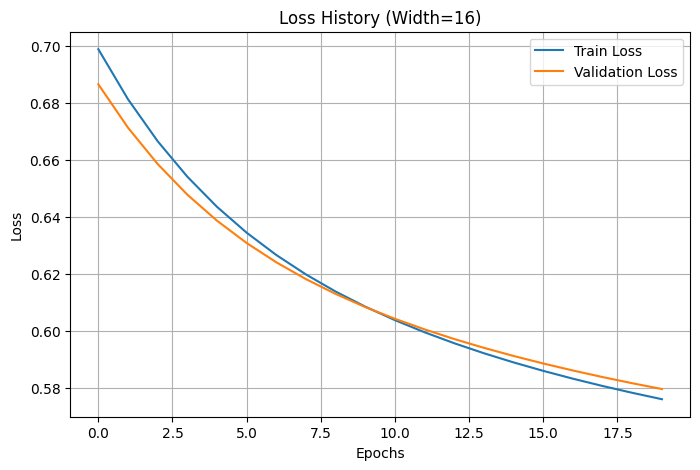

Distribusi Bobot dan Gradien untuk Width=16:


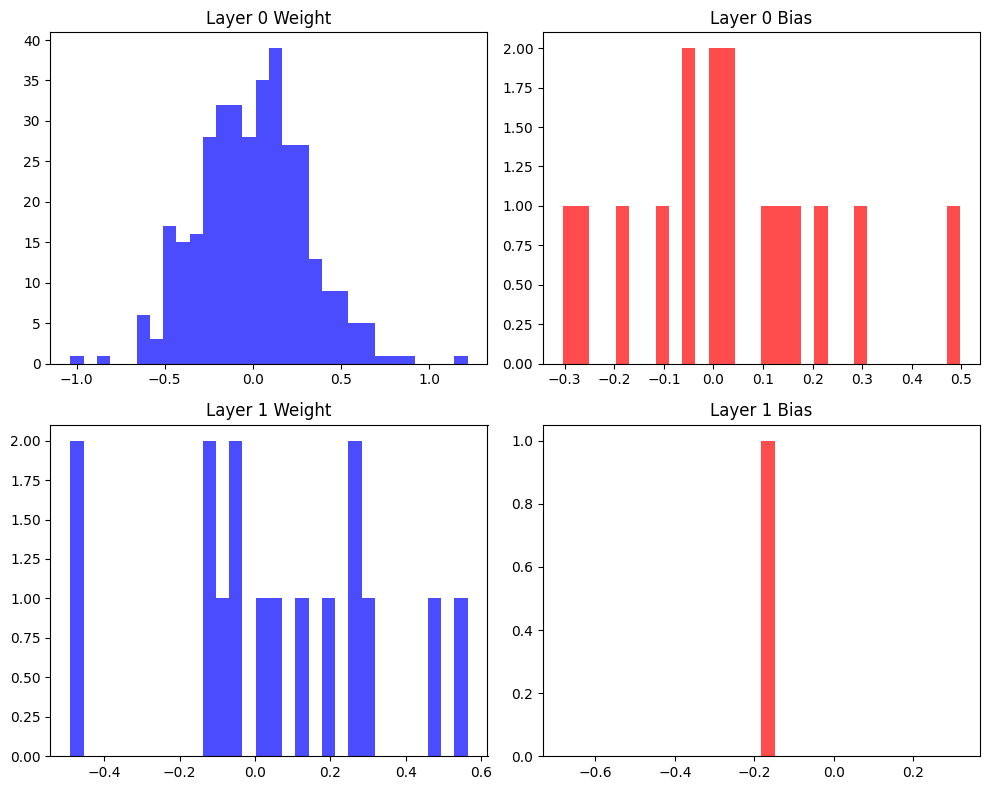

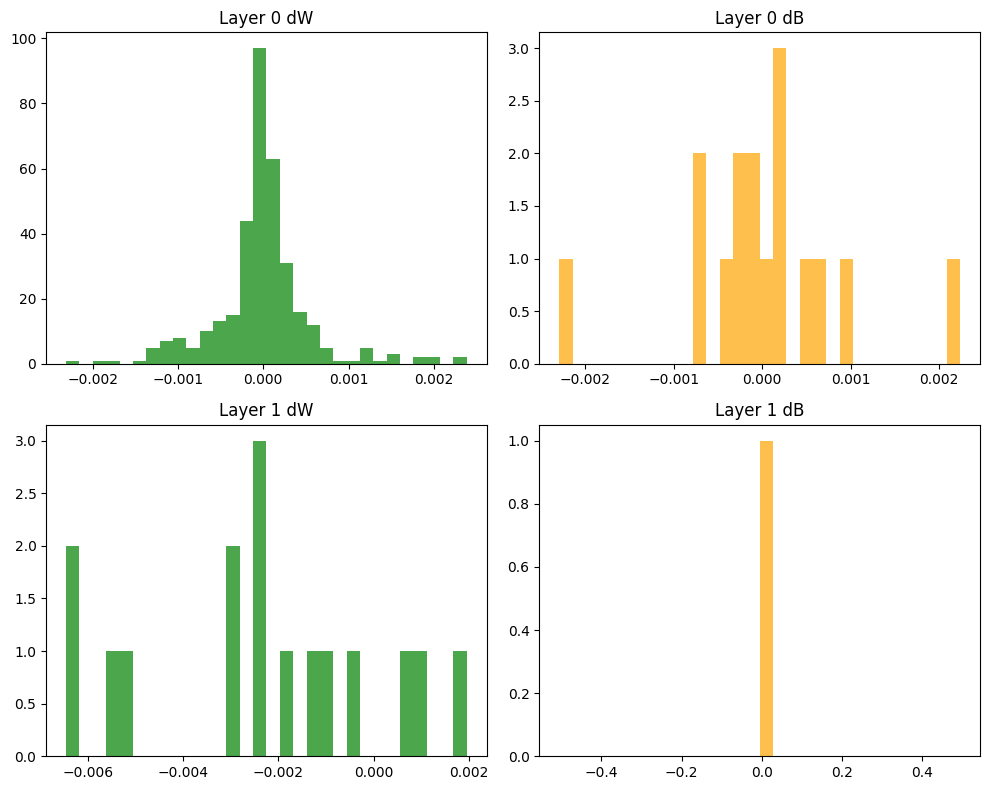


Melatih FFNN dengan 1 hidden layer (width=32)...
Epoch 1/20 [==============================] 100% - loss: 0.9626 - val_loss: 0.9213
Epoch 2/20 [==============================] 100% - loss: 0.9036 - val_loss: 0.8697
Epoch 3/20 [==============================] 100% - loss: 0.8568 - val_loss: 0.8288
Epoch 4/20 [==============================] 100% - loss: 0.8196 - val_loss: 0.7962
Epoch 5/20 [==============================] 100% - loss: 0.7897 - val_loss: 0.7700
Epoch 6/20 [==============================] 100% - loss: 0.7654 - val_loss: 0.7486
Epoch 7/20 [==============================] 100% - loss: 0.7455 - val_loss: 0.7309
Epoch 8/20 [==============================] 100% - loss: 0.7289 - val_loss: 0.7160
Epoch 9/20 [==============================] 100% - loss: 0.7148 - val_loss: 0.7032
Epoch 10/20 [==============================] 100% - loss: 0.7027 - val_loss: 0.6922
Epoch 11/20 [==============================] 100% - loss: 0.6922 - val_loss: 0.6824
Epoch 12/20 [======================

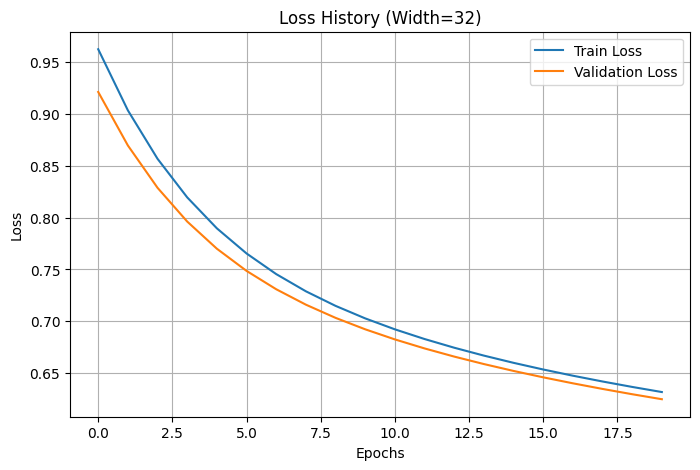

Distribusi Bobot dan Gradien untuk Width=32:


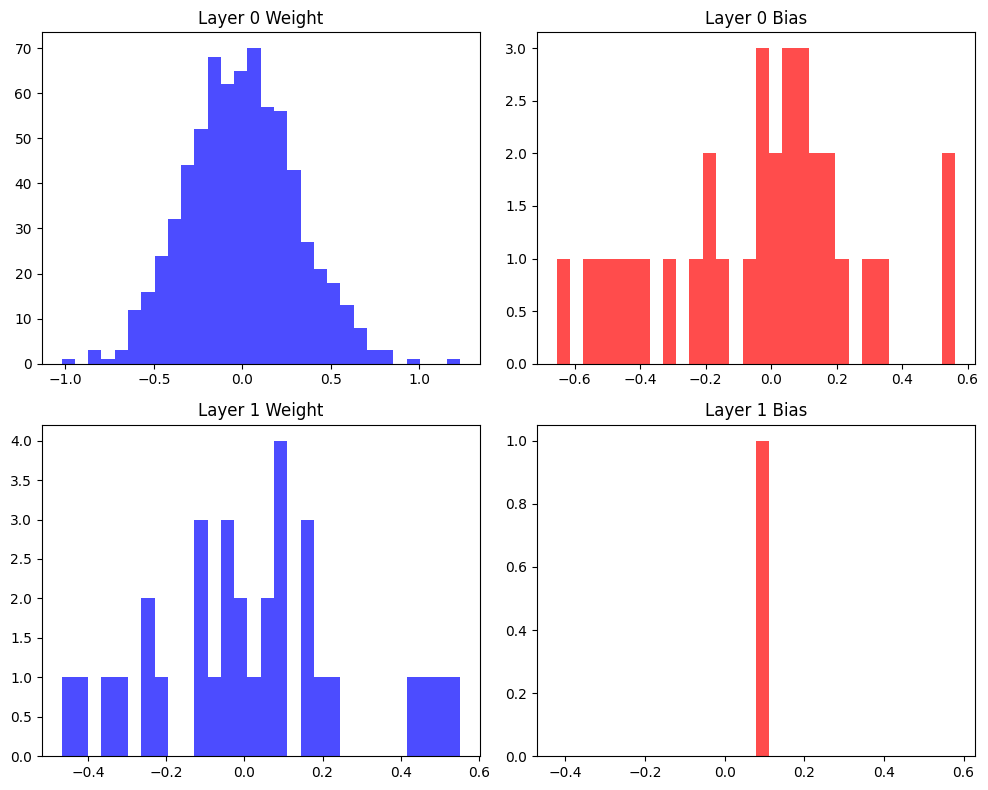

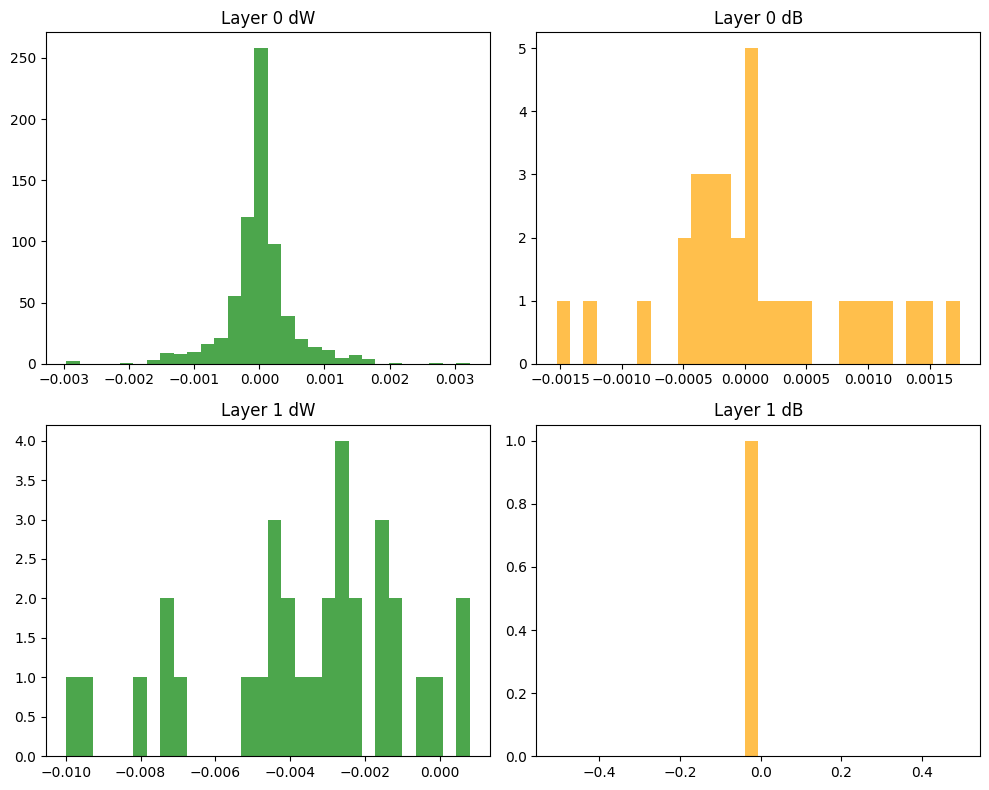


Melatih FFNN dengan 1 hidden layer (width=64)...
Epoch 1/20 [==============================] 100% - loss: 1.4410 - val_loss: 1.3068
Epoch 2/20 [==============================] 100% - loss: 1.2236 - val_loss: 1.1323
Epoch 3/20 [==============================] 100% - loss: 1.0828 - val_loss: 1.0194
Epoch 4/20 [==============================] 100% - loss: 0.9914 - val_loss: 0.9452
Epoch 5/20 [==============================] 100% - loss: 0.9307 - val_loss: 0.8947
Epoch 6/20 [==============================] 100% - loss: 0.8885 - val_loss: 0.8587
Epoch 7/20 [==============================] 100% - loss: 0.8575 - val_loss: 0.8314
Epoch 8/20 [==============================] 100% - loss: 0.8334 - val_loss: 0.8095
Epoch 9/20 [==============================] 100% - loss: 0.8136 - val_loss: 0.7910
Epoch 10/20 [==============================] 100% - loss: 0.7965 - val_loss: 0.7749
Epoch 11/20 [==============================] 100% - loss: 0.7814 - val_loss: 0.7605
Epoch 12/20 [======================

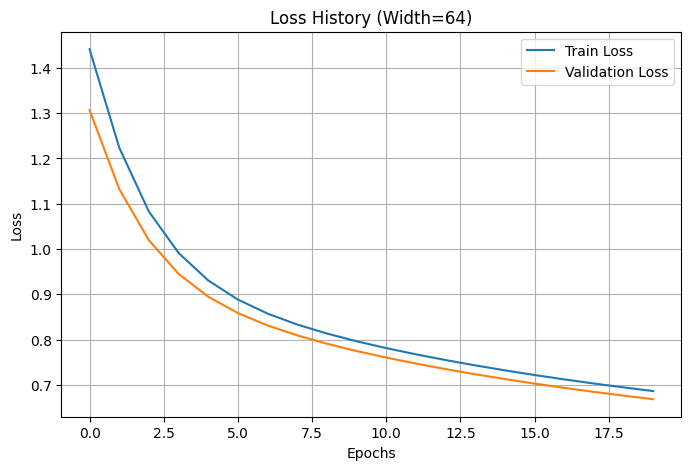

Distribusi Bobot dan Gradien untuk Width=64:


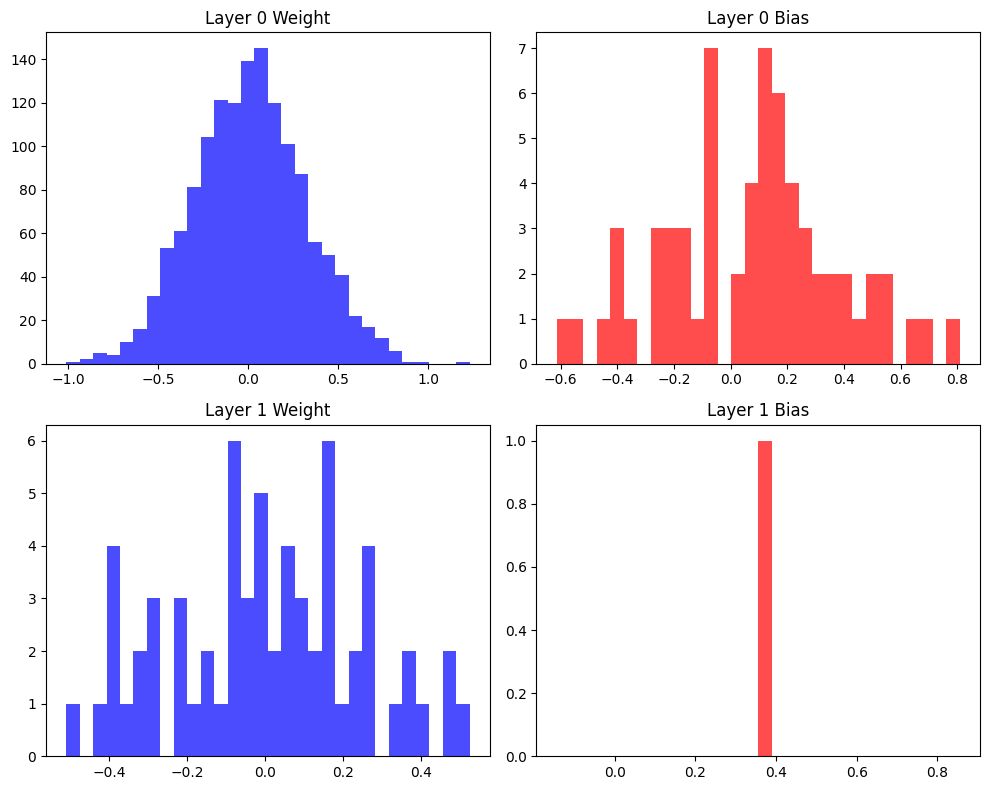

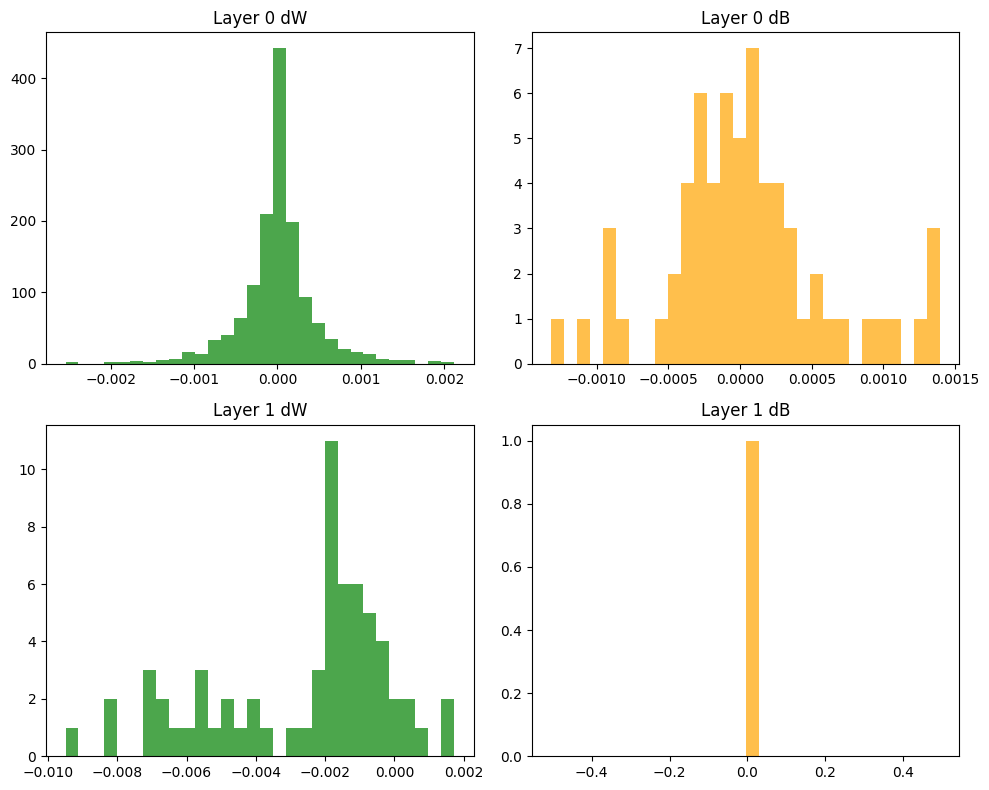

In [30]:
width_variations = [16, 32, 64]
history_width = {}
model_width = {}

for w in width_variations:
    print(f"\nMelatih FFNN dengan 1 hidden layer (width={w})...")
    model = FFNN(loss=BCE(), layers=[input_dim, w, output_dim], activation=[ReLU(), Sigmoid()], link_verbose=False, init_method='normal', mean=0, variance=0.1, seed=42)
    hist = model.fit(X_train_scaled, y_train_np, epochs=20, learning_rate=0.01, batch_size=32, verbose=1, X_val=X_val_scaled, y_val=y_val_np)
    
    y_pred_val = model.predict(X_val_scaled)
    acc = calculate_accuracy(y_val_np, y_pred_val)
    print(f"Width={w} - Validation Accuracy: {acc:.4f}, Final Val Loss: {hist['val_loss'][-1]:.4f}")
    
    history_width[w] = hist
    model_width[w] = model
    plot_history(hist, title=f"Loss History (Width={w})")
    
    print(f"Distribusi Bobot dan Gradien untuk Width={w}:")
    model.show_weight_distribution(layers=[0, 1])
    model.show_dw_distribution(layers=[0, 1])


#### 1.b. Variasi Depth dengan Width = 32


Melatih FFNN dengan 1 hidden layer(s) (width=32)...
Epoch 1/20 [==============================] 100% - loss: 0.9626 - val_loss: 0.9213
Epoch 2/20 [==============================] 100% - loss: 0.9036 - val_loss: 0.8697
Epoch 3/20 [==============================] 100% - loss: 0.8568 - val_loss: 0.8288
Epoch 4/20 [==============================] 100% - loss: 0.8196 - val_loss: 0.7962
Epoch 5/20 [==============================] 100% - loss: 0.7897 - val_loss: 0.7700
Epoch 6/20 [==============================] 100% - loss: 0.7654 - val_loss: 0.7486
Epoch 7/20 [==============================] 100% - loss: 0.7455 - val_loss: 0.7309
Epoch 8/20 [==============================] 100% - loss: 0.7289 - val_loss: 0.7160
Epoch 9/20 [==============================] 100% - loss: 0.7148 - val_loss: 0.7032
Epoch 10/20 [==============================] 100% - loss: 0.7027 - val_loss: 0.6922
Epoch 11/20 [==============================] 100% - loss: 0.6922 - val_loss: 0.6824
Epoch 12/20 [===================

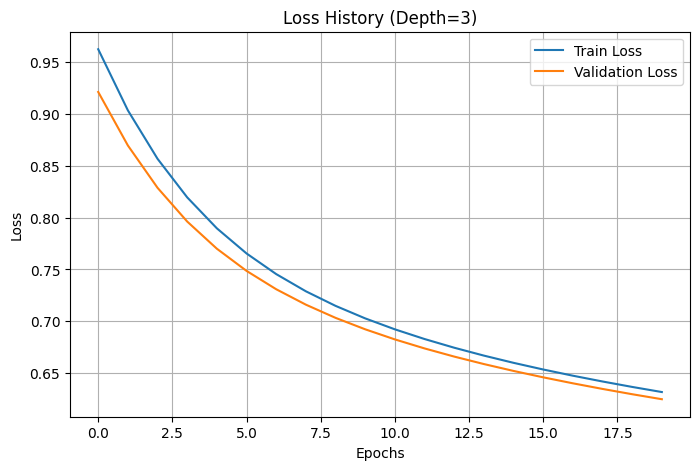

Distribusi Bobot dan Gradien untuk Depth=3:


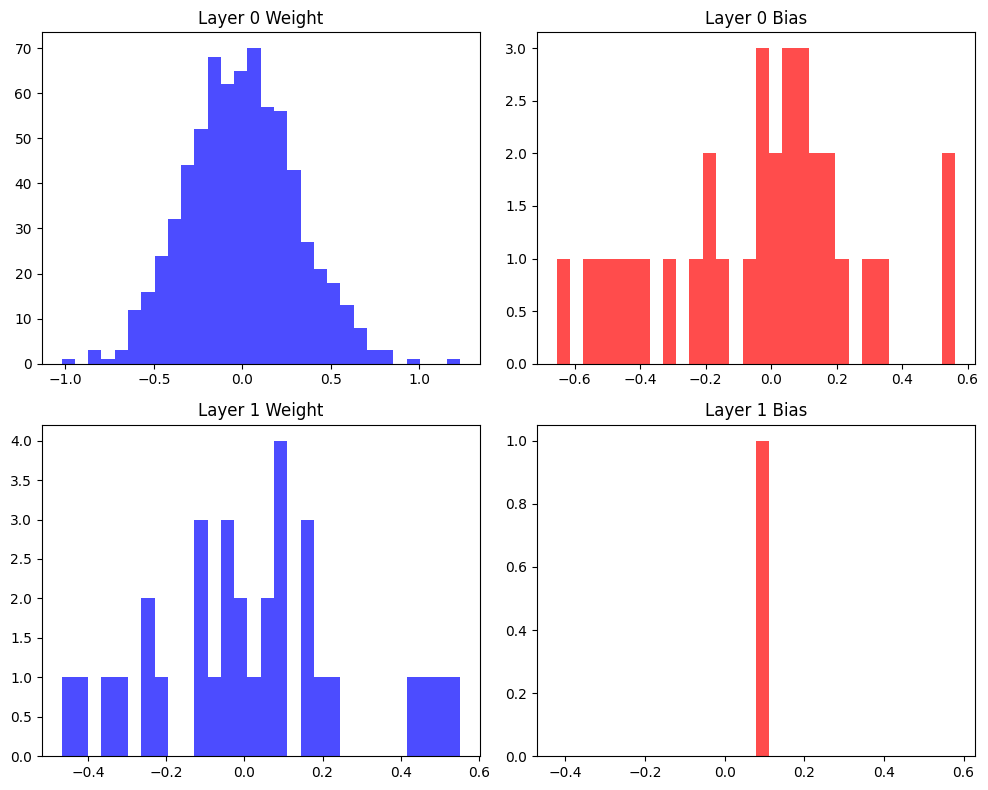

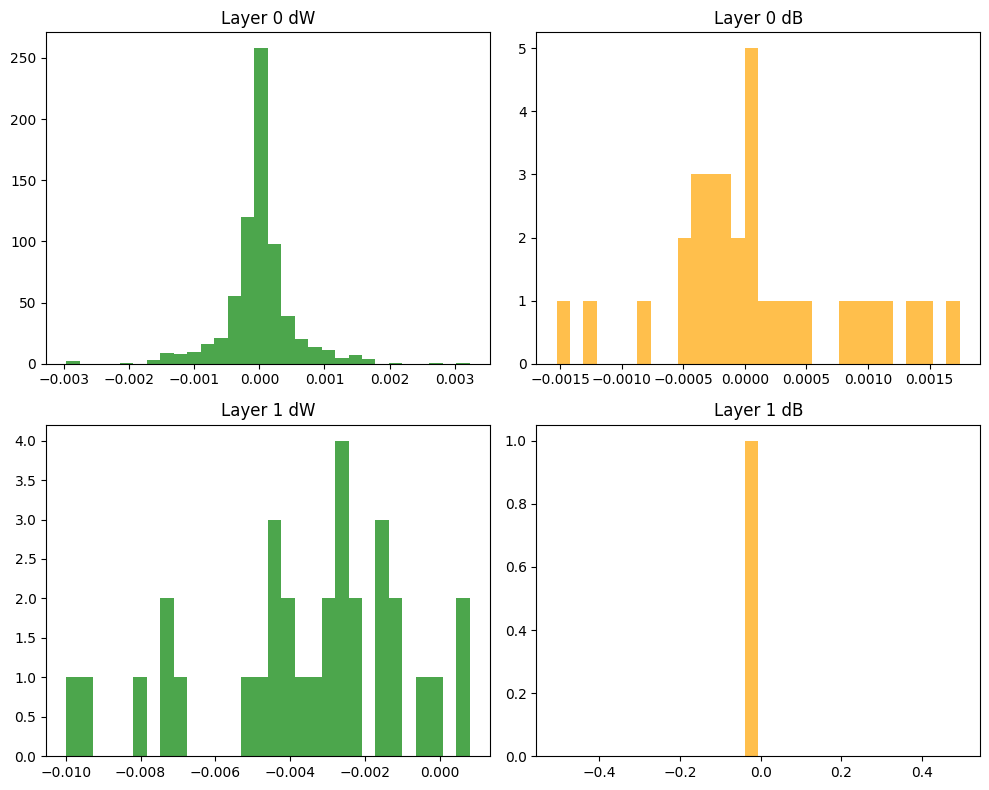


Melatih FFNN dengan 2 hidden layer(s) (width=32)...
Epoch 1/20 [==============================] 100% - loss: 1.2108 - val_loss: 1.0421
Epoch 2/20 [==============================] 100% - loss: 0.9806 - val_loss: 0.9018
Epoch 3/20 [==============================] 100% - loss: 0.8800 - val_loss: 0.8356
Epoch 4/20 [==============================] 100% - loss: 0.8282 - val_loss: 0.7966
Epoch 5/20 [==============================] 100% - loss: 0.7949 - val_loss: 0.7685
Epoch 6/20 [==============================] 100% - loss: 0.7697 - val_loss: 0.7460
Epoch 7/20 [==============================] 100% - loss: 0.7492 - val_loss: 0.7269
Epoch 8/20 [==============================] 100% - loss: 0.7317 - val_loss: 0.7106
Epoch 9/20 [==============================] 100% - loss: 0.7166 - val_loss: 0.6963
Epoch 10/20 [==============================] 100% - loss: 0.7035 - val_loss: 0.6839
Epoch 11/20 [==============================] 100% - loss: 0.6919 - val_loss: 0.6729
Epoch 12/20 [===================

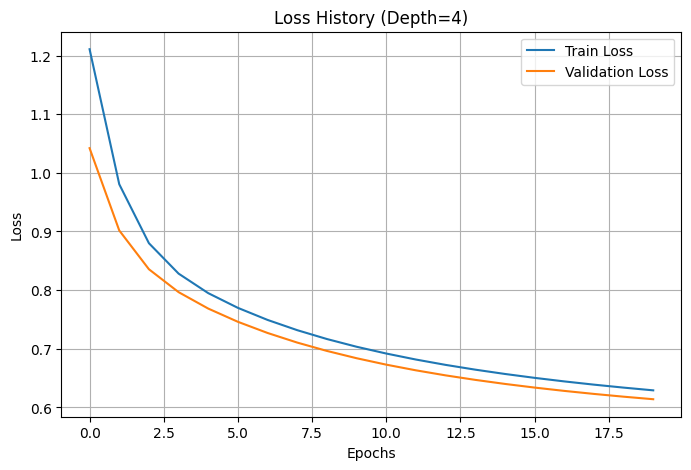

Distribusi Bobot dan Gradien untuk Depth=4:


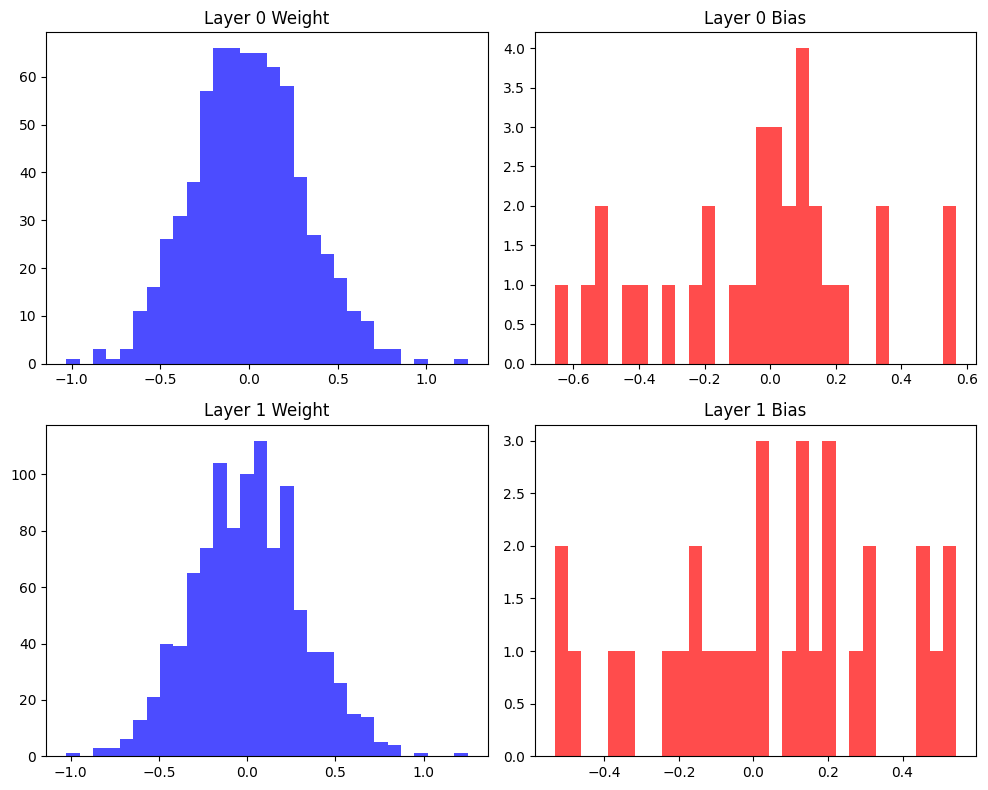

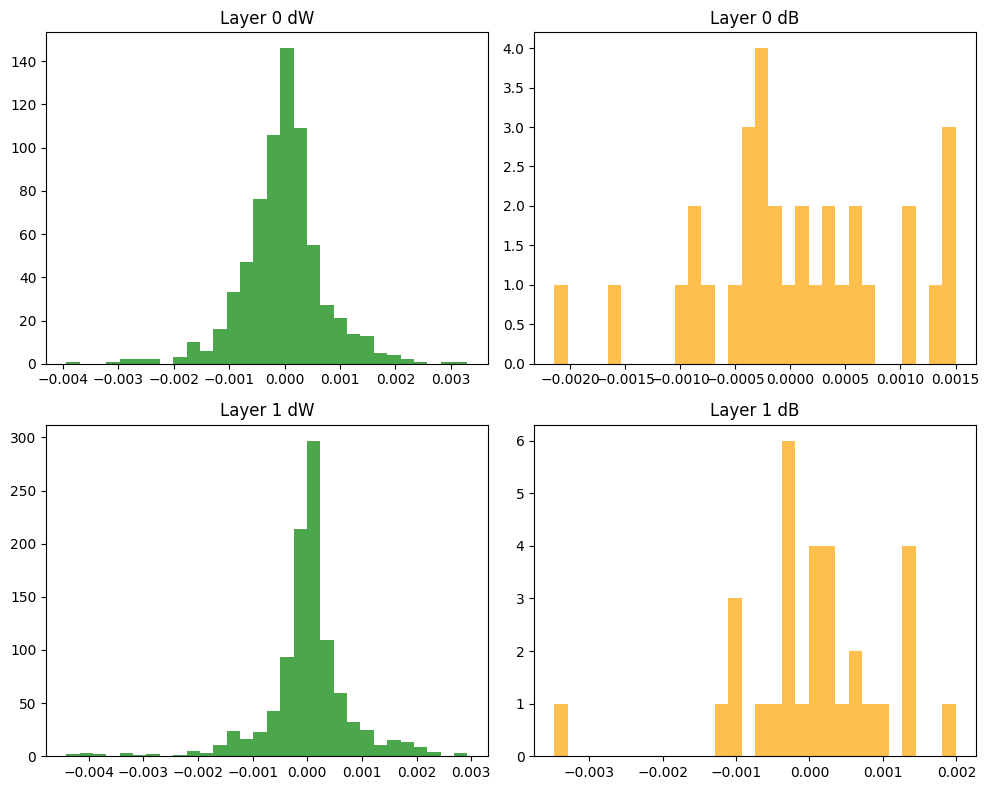


Melatih FFNN dengan 3 hidden layer(s) (width=32)...
Epoch 1/20 [==============================] 100% - loss: 1.4967 - val_loss: 1.1427
Epoch 2/20 [==============================] 100% - loss: 1.0383 - val_loss: 0.9436
Epoch 3/20 [==============================] 100% - loss: 0.9130 - val_loss: 0.8630
Epoch 4/20 [==============================] 100% - loss: 0.8474 - val_loss: 0.8126
Epoch 5/20 [==============================] 100% - loss: 0.8022 - val_loss: 0.7767
Epoch 6/20 [==============================] 100% - loss: 0.7688 - val_loss: 0.7494
Epoch 7/20 [==============================] 100% - loss: 0.7432 - val_loss: 0.7279
Epoch 8/20 [==============================] 100% - loss: 0.7228 - val_loss: 0.7105
Epoch 9/20 [==============================] 100% - loss: 0.7062 - val_loss: 0.6961
Epoch 10/20 [==============================] 100% - loss: 0.6924 - val_loss: 0.6838
Epoch 11/20 [==============================] 100% - loss: 0.6806 - val_loss: 0.6733
Epoch 12/20 [===================

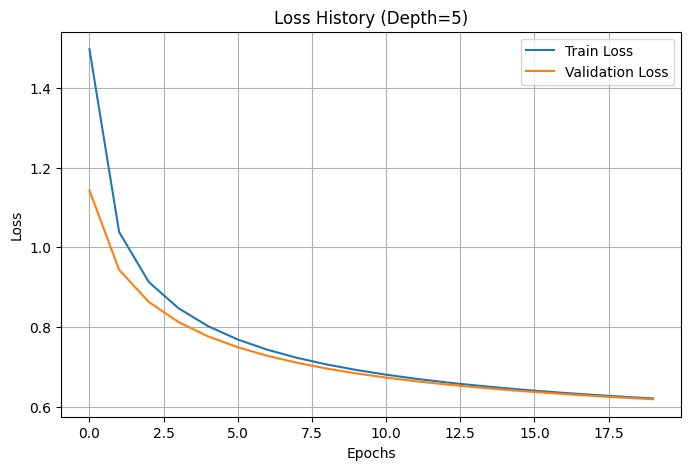

Distribusi Bobot dan Gradien untuk Depth=5:


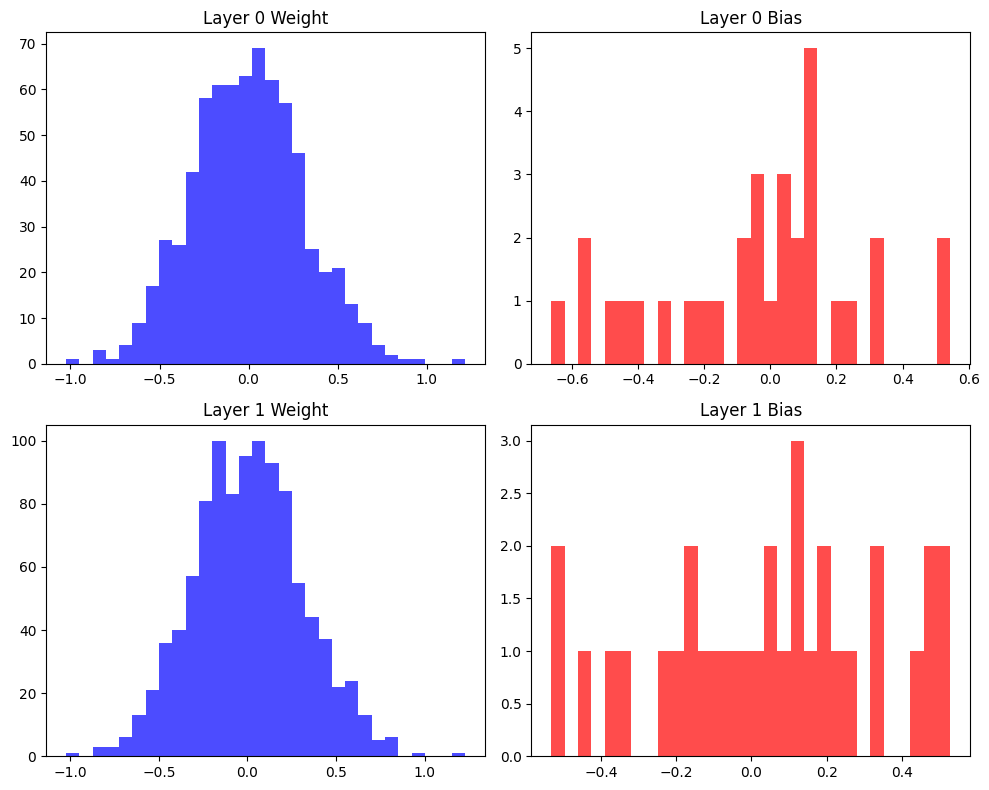

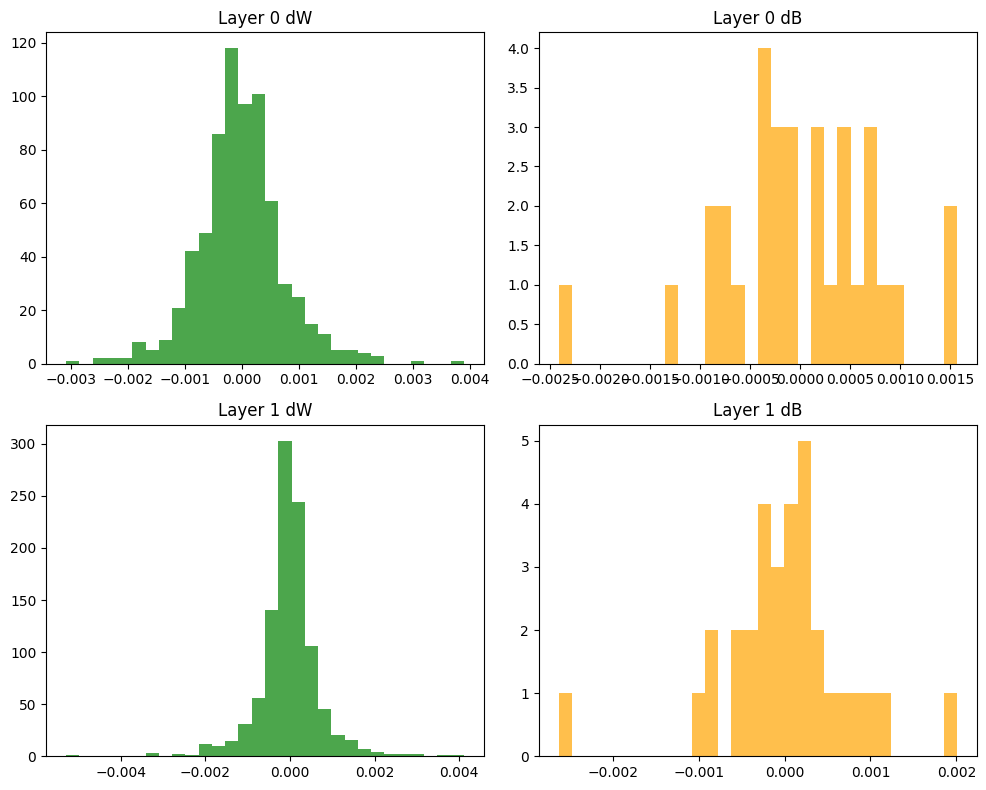

In [ ]:
depth_variations = [
    [input_dim, 32, output_dim],         # 1 hidden layer
    [input_dim, 32, 32, output_dim],     # 2 hidden layers
    [input_dim, 32, 32, 32, output_dim]  # 3 hidden layers
]
history_depth = {}
model_depth = {}

for i, layers in enumerate(depth_variations):
    depth = len(layers) - 1
    print(f"\nMelatih FFNN dengan {depth-1} hidden layer(s) (width=32)...")
    
    activations = [ReLU() for _ in range(depth - 1)] + [Sigmoid()] if depth > 1 else [Sigmoid()]
    
    model = FFNN(loss=BCE(), layers=layers, activation=activations, link_verbose=False, init_method='normal', mean=0, variance=0.1, seed=42)
    hist = model.fit(X_train_scaled, y_train_np, epochs=20, learning_rate=0.01, batch_size=32, verbose=1, X_val=X_val_scaled, y_val=y_val_np)
    
    y_pred_val = model.predict(X_val_scaled)
    acc = calculate_accuracy(y_val_np, y_pred_val)
    print(f"Depth={depth+1} - Validation Accuracy: {acc:.4f}, Final Val Loss: {hist['val_loss'][-1]:.4f}")
    
    history_depth[depth] = hist
    model_depth[depth] = model
    plot_history(hist, title=f"Loss History (Depth={depth+1})")
    
    print(f"Distribusi Bobot dan Gradien untuk Depth={depth+1}:")
    model.show_weight_distribution(layers=[0, 1])
    model.show_dw_distribution(layers=[0, 1])


### 2. Pengaruh Fungsi Aktivasi Hidden Layer
Base arsitektur: `[input_dim, 32, 32, output_dim]`.
Layer pengetesan: Hidden layer pertama (index 0).


Melatih FFNN dengan Fungsi Aktivasi Hidden layer 1: Linear
Epoch 1/20 [==============================] 100% - loss: 1.7875 - val_loss: 1.4460
Epoch 2/20 [==============================] 100% - loss: 1.3115 - val_loss: 1.1130
Epoch 3/20 [==============================] 100% - loss: 1.0650 - val_loss: 0.9417
Epoch 4/20 [==============================] 100% - loss: 0.9326 - val_loss: 0.8426
Epoch 5/20 [==============================] 100% - loss: 0.8506 - val_loss: 0.7764
Epoch 6/20 [==============================] 100% - loss: 0.7932 - val_loss: 0.7280
Epoch 7/20 [==============================] 100% - loss: 0.7500 - val_loss: 0.6912
Epoch 8/20 [==============================] 100% - loss: 0.7164 - val_loss: 0.6626
Epoch 9/20 [==============================] 100% - loss: 0.6898 - val_loss: 0.6399
Epoch 10/20 [==============================] 100% - loss: 0.6683 - val_loss: 0.6217
Epoch 11/20 [==============================] 100% - loss: 0.6508 - val_loss: 0.6069
Epoch 12/20 [============

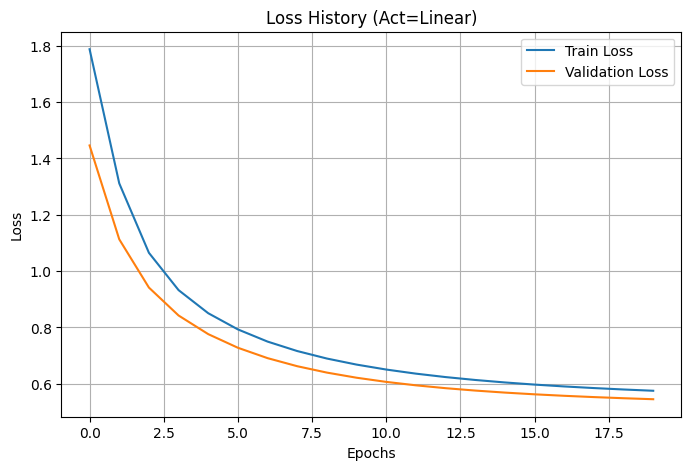

Distribusi Bobot dan Gradien untuk Linear di layer 0 (Layer Pengetesan):


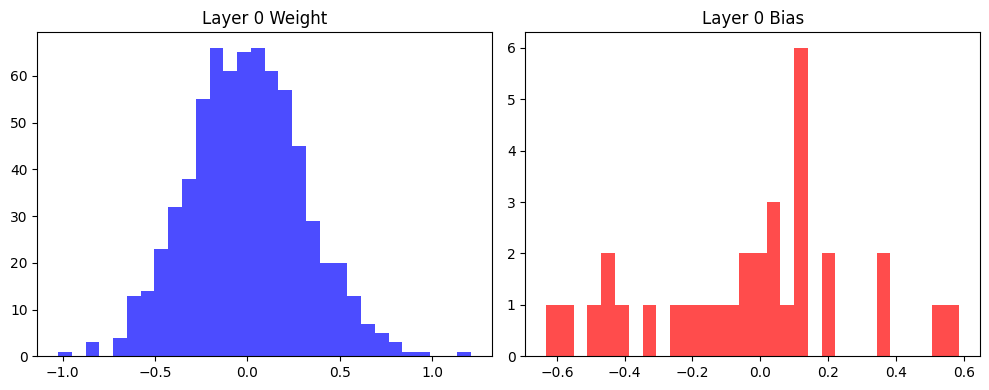

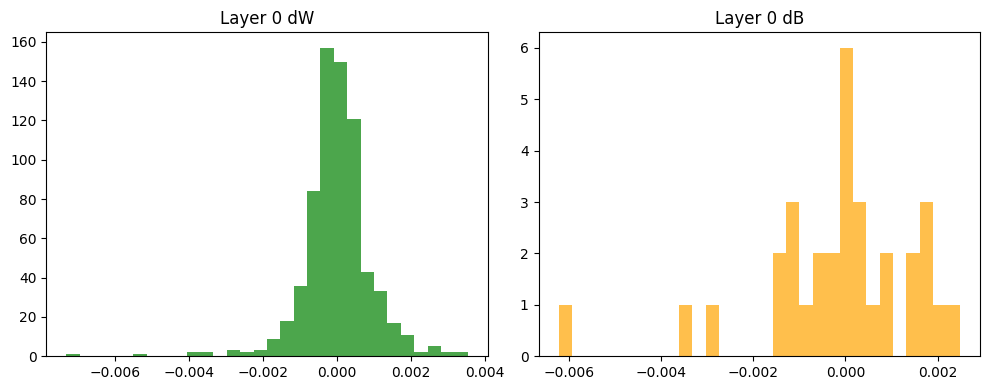


Melatih FFNN dengan Fungsi Aktivasi Hidden layer 1: ReLU
Epoch 1/20 [==============================] 100% - loss: 1.2108 - val_loss: 1.0421
Epoch 2/20 [==============================] 100% - loss: 0.9806 - val_loss: 0.9018
Epoch 3/20 [==============================] 100% - loss: 0.8800 - val_loss: 0.8356
Epoch 4/20 [==============================] 100% - loss: 0.8282 - val_loss: 0.7966
Epoch 5/20 [==============================] 100% - loss: 0.7949 - val_loss: 0.7685
Epoch 6/20 [==============================] 100% - loss: 0.7697 - val_loss: 0.7460
Epoch 7/20 [==============================] 100% - loss: 0.7492 - val_loss: 0.7269
Epoch 8/20 [==============================] 100% - loss: 0.7317 - val_loss: 0.7106
Epoch 9/20 [==============================] 100% - loss: 0.7166 - val_loss: 0.6963
Epoch 10/20 [==============================] 100% - loss: 0.7035 - val_loss: 0.6839
Epoch 11/20 [==============================] 100% - loss: 0.6919 - val_loss: 0.6729
Epoch 12/20 [==============

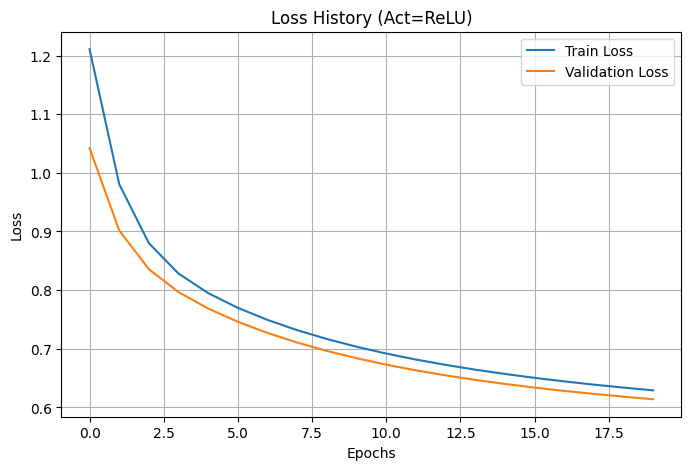

Distribusi Bobot dan Gradien untuk ReLU di layer 0 (Layer Pengetesan):


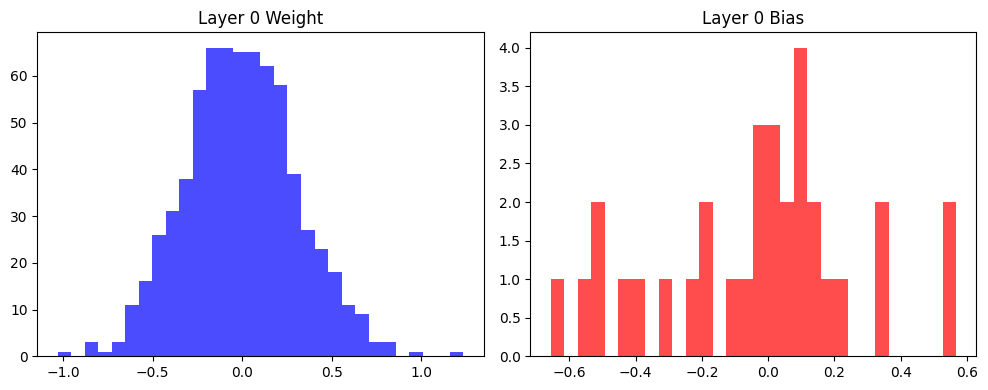

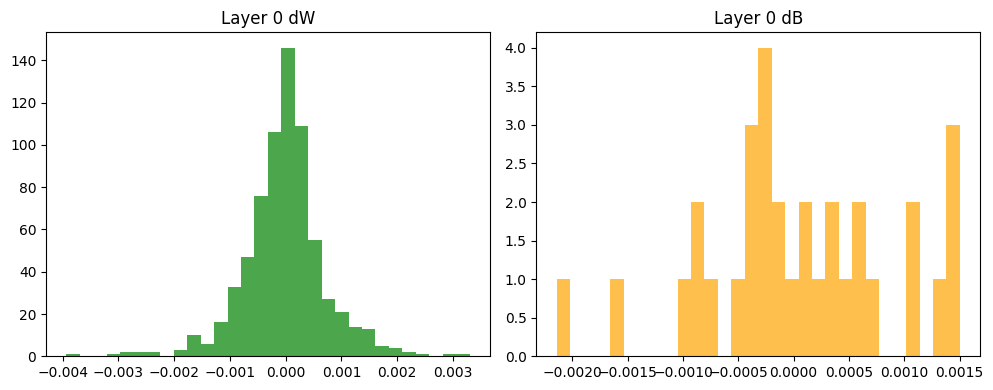


Melatih FFNN dengan Fungsi Aktivasi Hidden layer 1: Sigmoid
Epoch 1/20 [==============================] 100% - loss: 0.8573 - val_loss: 0.7855
Epoch 2/20 [==============================] 100% - loss: 0.7657 - val_loss: 0.7280
Epoch 3/20 [==============================] 100% - loss: 0.7245 - val_loss: 0.7014
Epoch 4/20 [==============================] 100% - loss: 0.7043 - val_loss: 0.6875
Epoch 5/20 [==============================] 100% - loss: 0.6927 - val_loss: 0.6788
Epoch 6/20 [==============================] 100% - loss: 0.6850 - val_loss: 0.6724
Epoch 7/20 [==============================] 100% - loss: 0.6790 - val_loss: 0.6670
Epoch 8/20 [==============================] 100% - loss: 0.6738 - val_loss: 0.6621
Epoch 9/20 [==============================] 100% - loss: 0.6691 - val_loss: 0.6576
Epoch 10/20 [==============================] 100% - loss: 0.6647 - val_loss: 0.6533
Epoch 11/20 [==============================] 100% - loss: 0.6605 - val_loss: 0.6491
Epoch 12/20 [===========

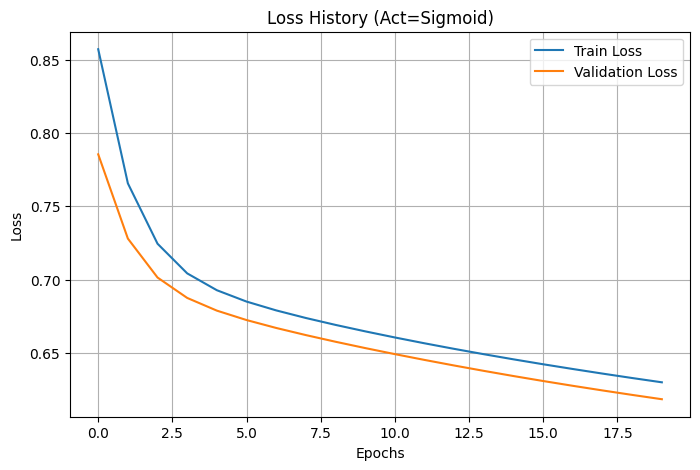

Distribusi Bobot dan Gradien untuk Sigmoid di layer 0 (Layer Pengetesan):


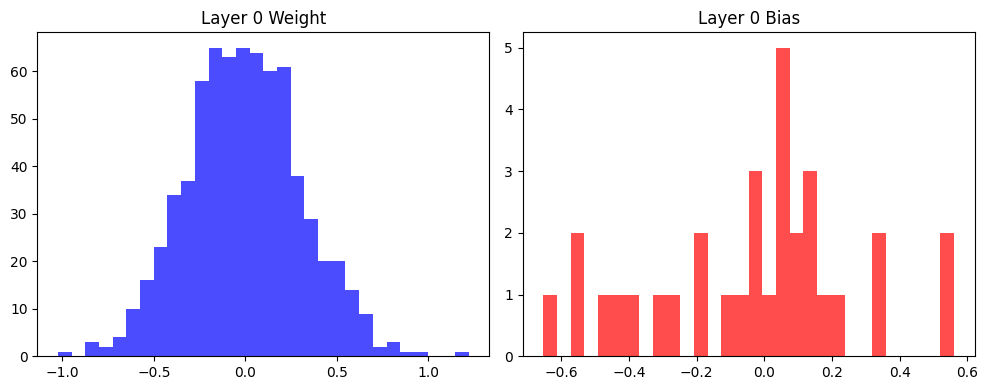

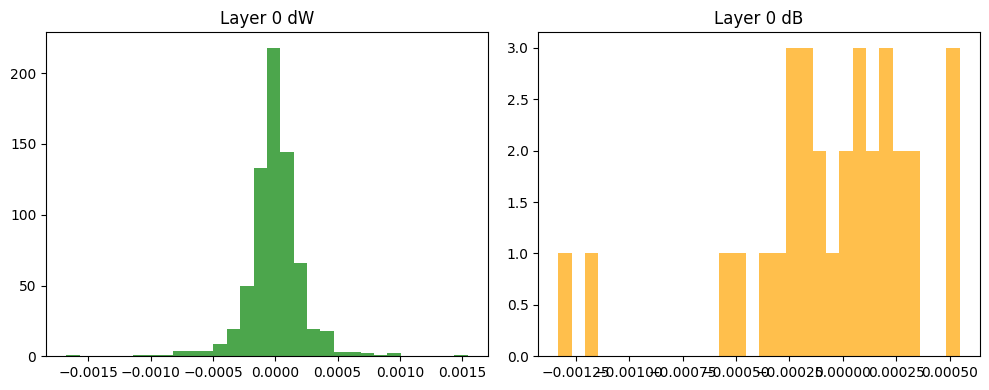


Melatih FFNN dengan Fungsi Aktivasi Hidden layer 1: Tanh
Epoch 1/20 [===================...........] 64%

c:\ITB\Semester_6\ML\KasihTauMama\src\activation.py:50: RuntimeWarning: overflow encountered in exp
  return  grad * (2 / (np.exp(self.val) - np.exp(-self.val))) ** 2


Epoch 1/20 [==============================] 100% - loss: 0.8800 - val_loss: 0.8087
Epoch 2/20 [==============================] 100% - loss: 0.7775 - val_loss: 0.7801
Epoch 3/20 [==============================] 100% - loss: 0.8476 - val_loss: 0.9671
Epoch 4/20 [==============================] 100% - loss: 0.9168 - val_loss: 0.9703
Epoch 5/20 [==============================] 100% - loss: 0.8978 - val_loss: 0.9492
Epoch 6/20 [==============================] 100% - loss: 0.8546 - val_loss: 0.8794
Epoch 7/20 [==============================] 100% - loss: 0.8243 - val_loss: 0.8541
Epoch 8/20 [==============================] 100% - loss: 0.8436 - val_loss: 0.8593
Epoch 9/20 [==============================] 100% - loss: 0.8205 - val_loss: 0.8374
Epoch 10/20 [==============================] 100% - loss: 0.8000 - val_loss: 0.8194
Epoch 11/20 [==============================] 100% - loss: 0.7845 - val_loss: 0.7972
Epoch 12/20 [==============================] 100% - loss: 0.7718 - val_loss: 0.7965
E

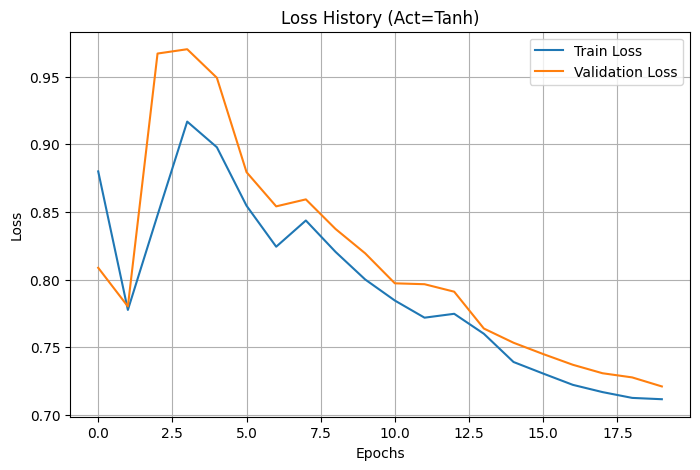

Distribusi Bobot dan Gradien untuk Tanh di layer 0 (Layer Pengetesan):


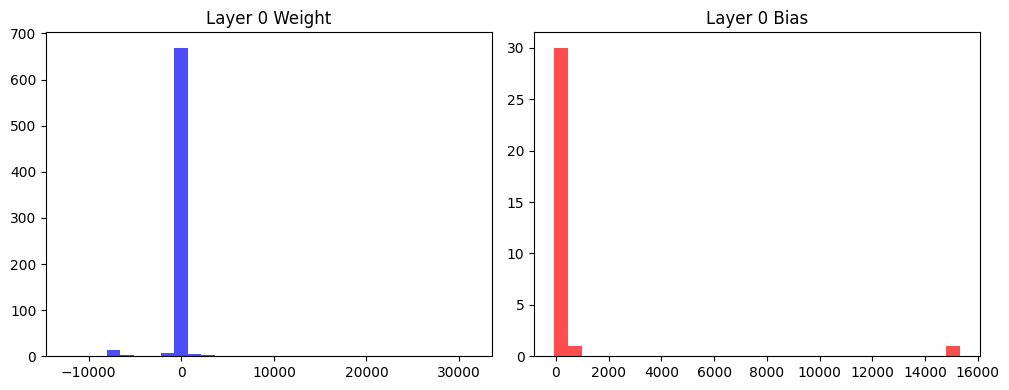

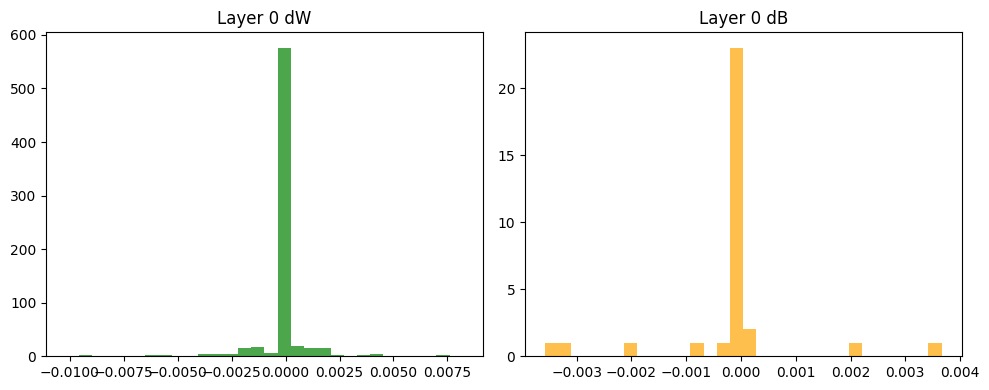

In [32]:
act_functions = {
    "Linear": Linear(),
    "ReLU": ReLU(),
    "Sigmoid": Sigmoid(),
    "Tanh": HyperbolicTangent()
}

history_act = {}
model_act = {}

for name, act in act_functions.items():
    print(f"\nMelatih FFNN dengan Fungsi Aktivasi Hidden layer 1: {name}")
    activations = [act, ReLU(), Sigmoid()]
    
    model = FFNN(loss=BCE(), layers=[input_dim, 32, 32, output_dim], activation=activations, link_verbose=False, init_method='normal', mean=0, variance=0.1, seed=42)
    hist = model.fit(X_train_scaled, y_train_np, epochs=20, learning_rate=0.01, batch_size=32, verbose=1, X_val=X_val_scaled, y_val=y_val_np)
    
    y_pred_val = model.predict(X_val_scaled)
    acc = calculate_accuracy(y_val_np, y_pred_val)
    print(f"Aktivasi {name} - Val Acc: {acc:.4f}, Final Val Loss: {hist['val_loss'][-1]:.4f}")
    
    history_act[name] = hist
    model_act[name] = model
    plot_history(hist, title=f"Loss History (Act={name})")
    
    print(f"Distribusi Bobot dan Gradien untuk {name} di layer 0 (Layer Pengetesan):")
    model.show_weight_distribution(layers=[0])
    model.show_dw_distribution(layers=[0])


### 3. Pengaruh Learning Rate


Melatih FFNN dengan Learning Rate = 0.1
Epoch 1/20 [==============================] 100% - loss: 0.8387 - val_loss: 0.6838
Epoch 2/20 [==============================] 100% - loss: 0.6577 - val_loss: 0.6142
Epoch 3/20 [==============================] 100% - loss: 0.6109 - val_loss: 0.5848
Epoch 4/20 [==============================] 100% - loss: 0.5876 - val_loss: 0.5683
Epoch 5/20 [==============================] 100% - loss: 0.5734 - val_loss: 0.5576
Epoch 6/20 [==============================] 100% - loss: 0.5637 - val_loss: 0.5499
Epoch 7/20 [==============================] 100% - loss: 0.5566 - val_loss: 0.5441
Epoch 8/20 [==============================] 100% - loss: 0.5510 - val_loss: 0.5396
Epoch 9/20 [==============================] 100% - loss: 0.5465 - val_loss: 0.5358
Epoch 10/20 [==============================] 100% - loss: 0.5427 - val_loss: 0.5327
Epoch 11/20 [==============================] 100% - loss: 0.5395 - val_loss: 0.5300
Epoch 12/20 [==============================]

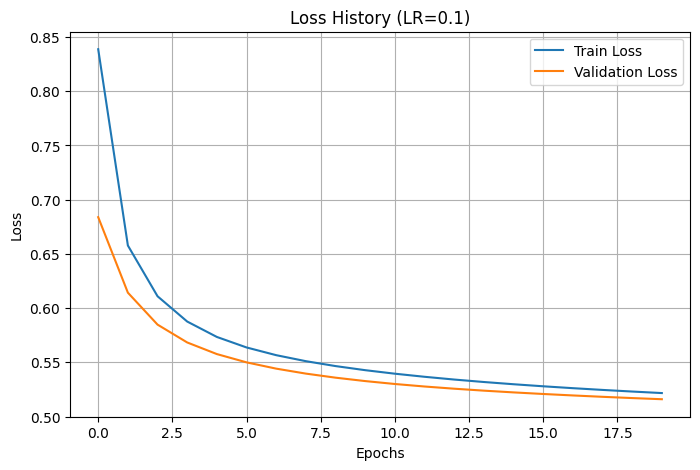

Distribusi Bobot dan Gradien untuk LR=0.1:


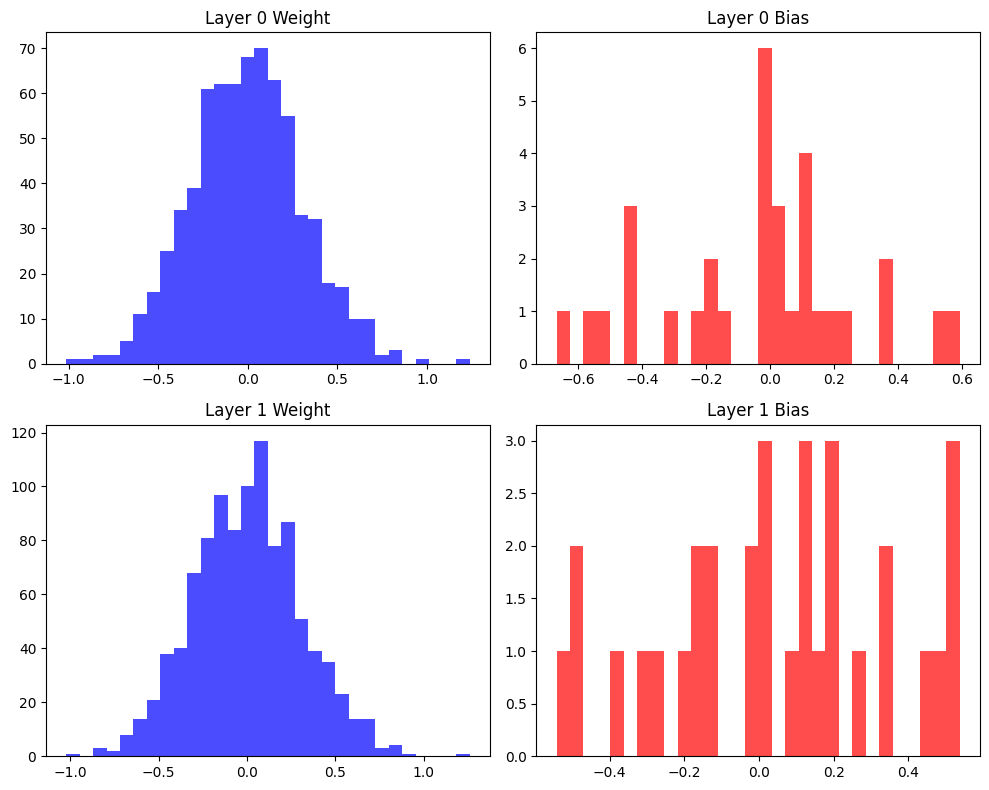

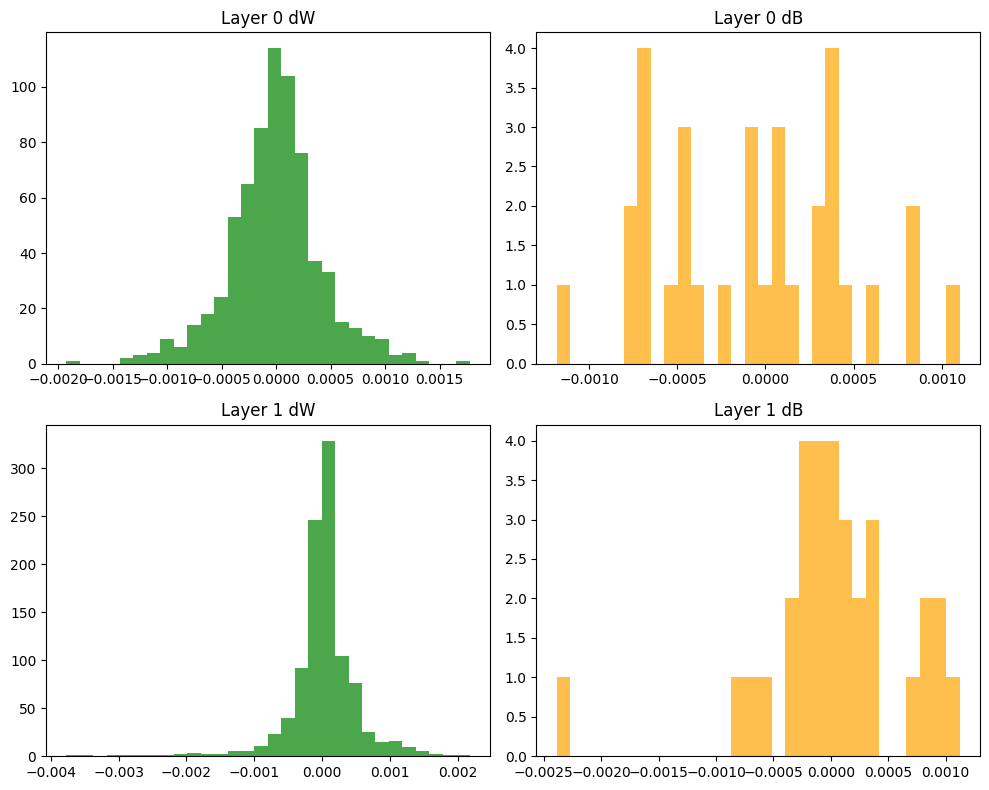


Melatih FFNN dengan Learning Rate = 0.01
Epoch 1/20 [==============================] 100% - loss: 1.2108 - val_loss: 1.0421
Epoch 2/20 [==============================] 100% - loss: 0.9806 - val_loss: 0.9018
Epoch 3/20 [==============================] 100% - loss: 0.8800 - val_loss: 0.8356
Epoch 4/20 [==============================] 100% - loss: 0.8282 - val_loss: 0.7966
Epoch 5/20 [==============================] 100% - loss: 0.7949 - val_loss: 0.7685
Epoch 6/20 [==============================] 100% - loss: 0.7697 - val_loss: 0.7460
Epoch 7/20 [==============================] 100% - loss: 0.7492 - val_loss: 0.7269
Epoch 8/20 [==============================] 100% - loss: 0.7317 - val_loss: 0.7106
Epoch 9/20 [==============================] 100% - loss: 0.7166 - val_loss: 0.6963
Epoch 10/20 [==============================] 100% - loss: 0.7035 - val_loss: 0.6839
Epoch 11/20 [==============================] 100% - loss: 0.6919 - val_loss: 0.6729
Epoch 12/20 [==============================

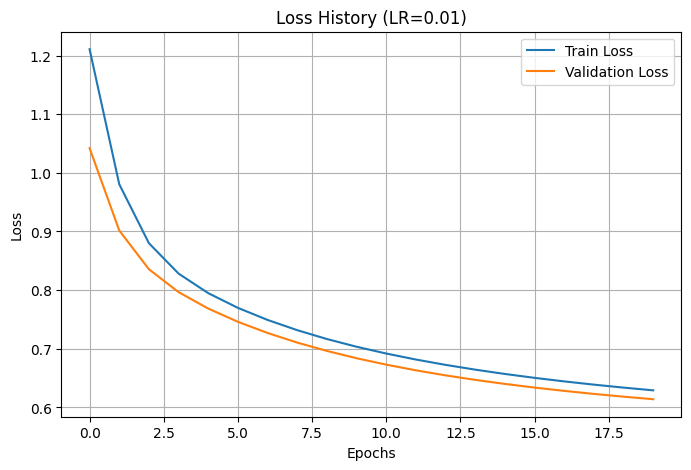

Distribusi Bobot dan Gradien untuk LR=0.01:


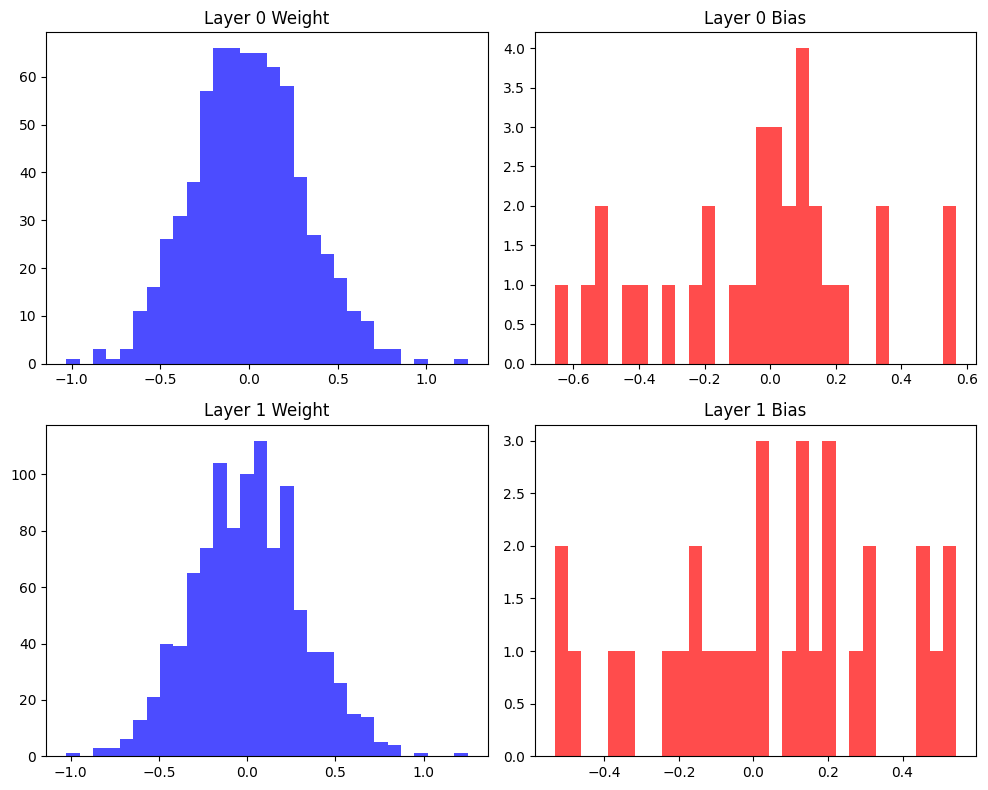

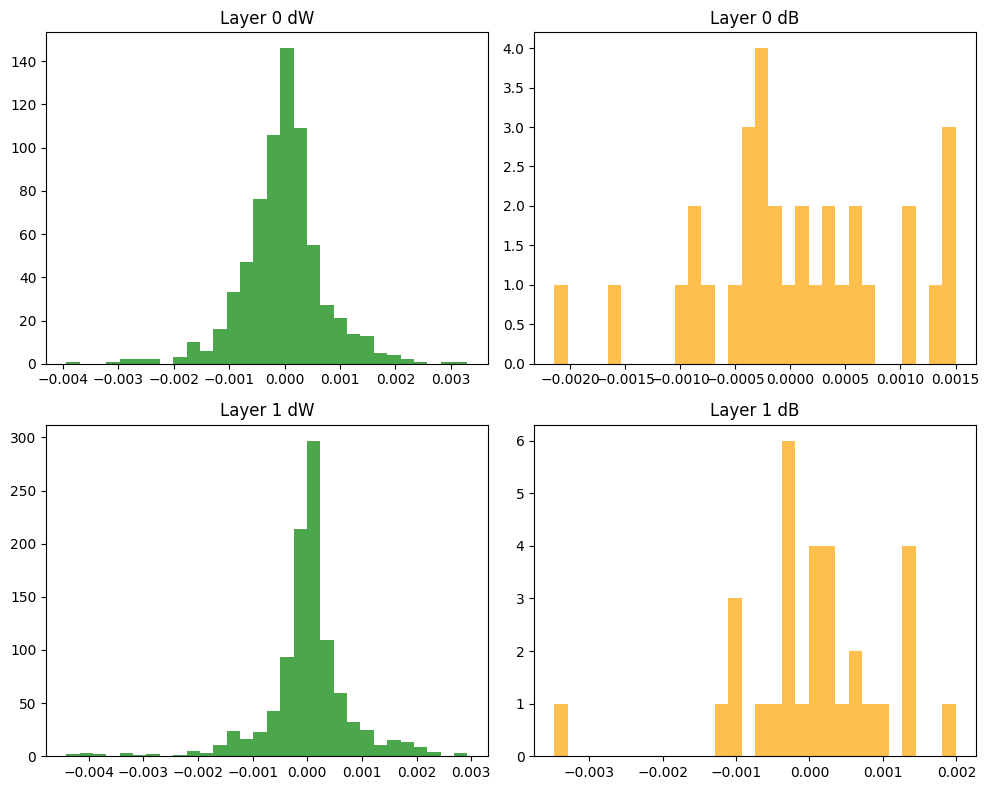


Melatih FFNN dengan Learning Rate = 0.001
Epoch 1/20 [==============================] 100% - loss: 1.3804 - val_loss: 1.3255
Epoch 2/20 [==============================] 100% - loss: 1.3340 - val_loss: 1.2825
Epoch 3/20 [==============================] 100% - loss: 1.2913 - val_loss: 1.2429
Epoch 4/20 [==============================] 100% - loss: 1.2519 - val_loss: 1.2065
Epoch 5/20 [==============================] 100% - loss: 1.2156 - val_loss: 1.1729
Epoch 6/20 [==============================] 100% - loss: 1.1823 - val_loss: 1.1422
Epoch 7/20 [==============================] 100% - loss: 1.1517 - val_loss: 1.1139
Epoch 8/20 [==============================] 100% - loss: 1.1236 - val_loss: 1.0880
Epoch 9/20 [==============================] 100% - loss: 1.0979 - val_loss: 1.0642
Epoch 10/20 [==============================] 100% - loss: 1.0743 - val_loss: 1.0425
Epoch 11/20 [==============================] 100% - loss: 1.0527 - val_loss: 1.0225
Epoch 12/20 [=============================

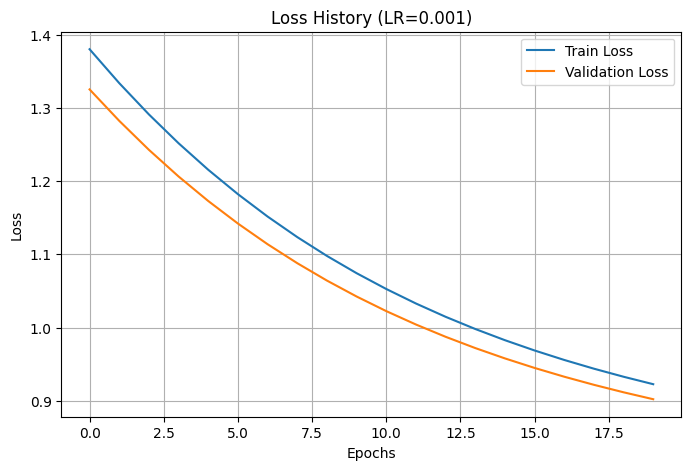

Distribusi Bobot dan Gradien untuk LR=0.001:


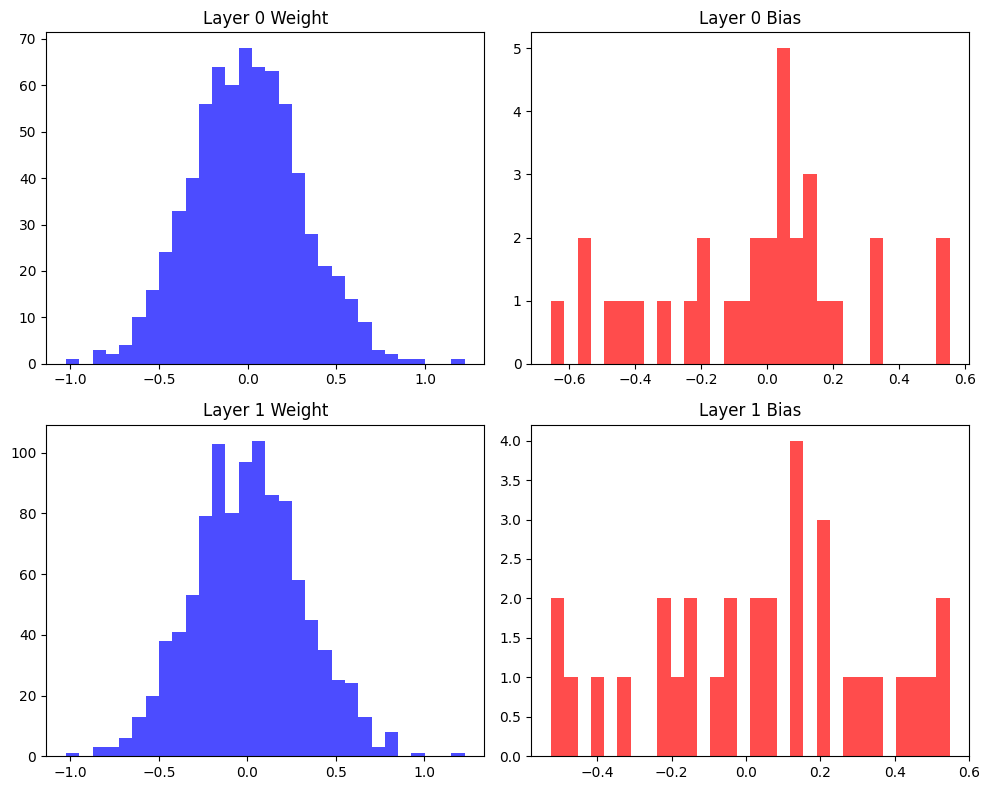

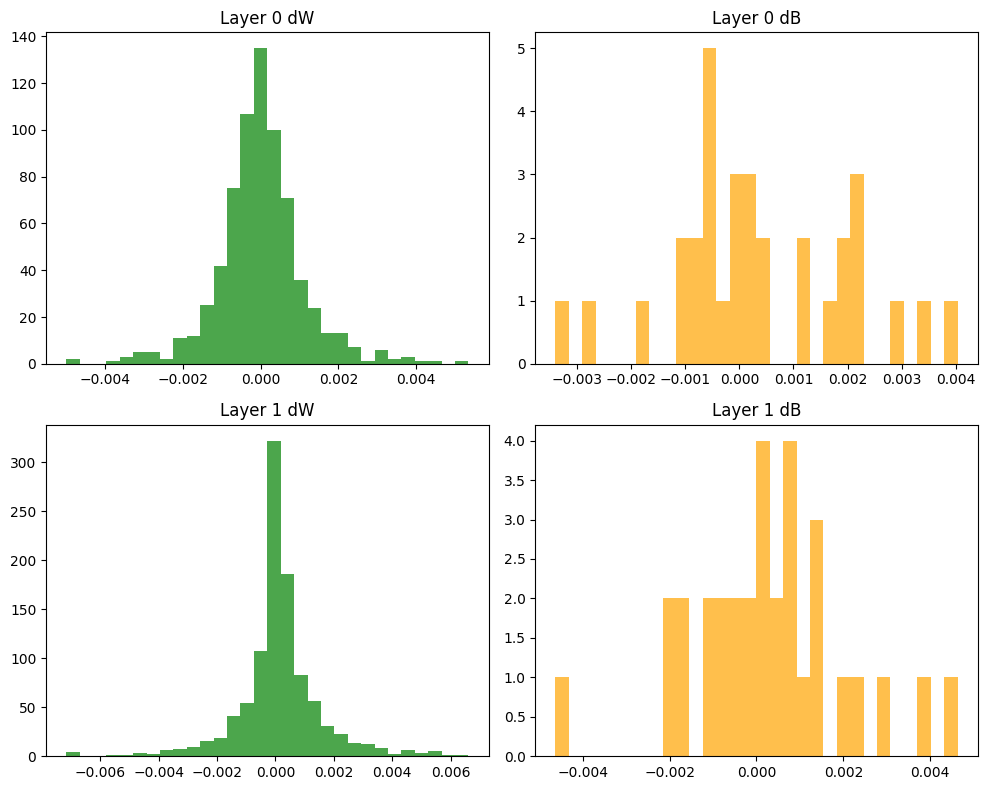

In [33]:
lr_variations = [0.1, 0.01, 0.001]
history_lr = {}
model_lr = {}

for lr in lr_variations:
    print(f"\nMelatih FFNN dengan Learning Rate = {lr}")
    model = FFNN(loss=BCE(), layers=[input_dim, 32, 32, output_dim], activation=[ReLU(), ReLU(), Sigmoid()], link_verbose=False, init_method='normal', mean=0, variance=0.1, seed=42)
    hist = model.fit(X_train_scaled, y_train_np, epochs=20, learning_rate=lr, batch_size=32, verbose=1, X_val=X_val_scaled, y_val=y_val_np)
    
    y_pred_val = model.predict(X_val_scaled)
    acc = calculate_accuracy(y_val_np, y_pred_val)
    print(f"LR={lr} - Val Acc: {acc:.4f}, Final Val Loss: {hist['val_loss'][-1]:.4f}")
    
    history_lr[lr] = hist
    model_lr[lr] = model
    plot_history(hist, title=f"Loss History (LR={lr})")
    print(f"Distribusi Bobot dan Gradien untuk LR={lr}:")
    model.show_weight_distribution(layers=[0, 1])
    model.show_dw_distribution(layers=[0, 1])


### 4. Pengaruh Regularisasi


Melatih FFNN: Tanpa Regularisasi
Epoch 1/20 [==============================] 100% - loss: 1.2108 - val_loss: 1.0421
Epoch 2/20 [==============================] 100% - loss: 0.9806 - val_loss: 0.9018
Epoch 3/20 [==============================] 100% - loss: 0.8800 - val_loss: 0.8356
Epoch 4/20 [==============================] 100% - loss: 0.8282 - val_loss: 0.7966
Epoch 5/20 [==============================] 100% - loss: 0.7949 - val_loss: 0.7685
Epoch 6/20 [==============================] 100% - loss: 0.7697 - val_loss: 0.7460
Epoch 7/20 [==============================] 100% - loss: 0.7492 - val_loss: 0.7269
Epoch 8/20 [==============================] 100% - loss: 0.7317 - val_loss: 0.7106
Epoch 9/20 [==============================] 100% - loss: 0.7166 - val_loss: 0.6963
Epoch 10/20 [==============================] 100% - loss: 0.7035 - val_loss: 0.6839
Epoch 11/20 [==============================] 100% - loss: 0.6919 - val_loss: 0.6729
Epoch 12/20 [==============================] 100% -

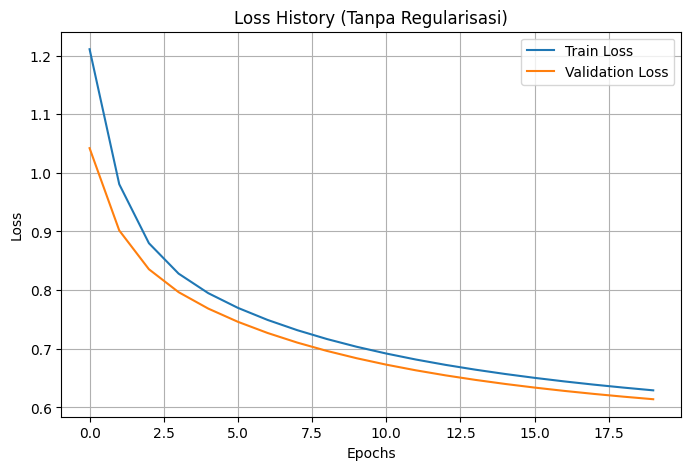

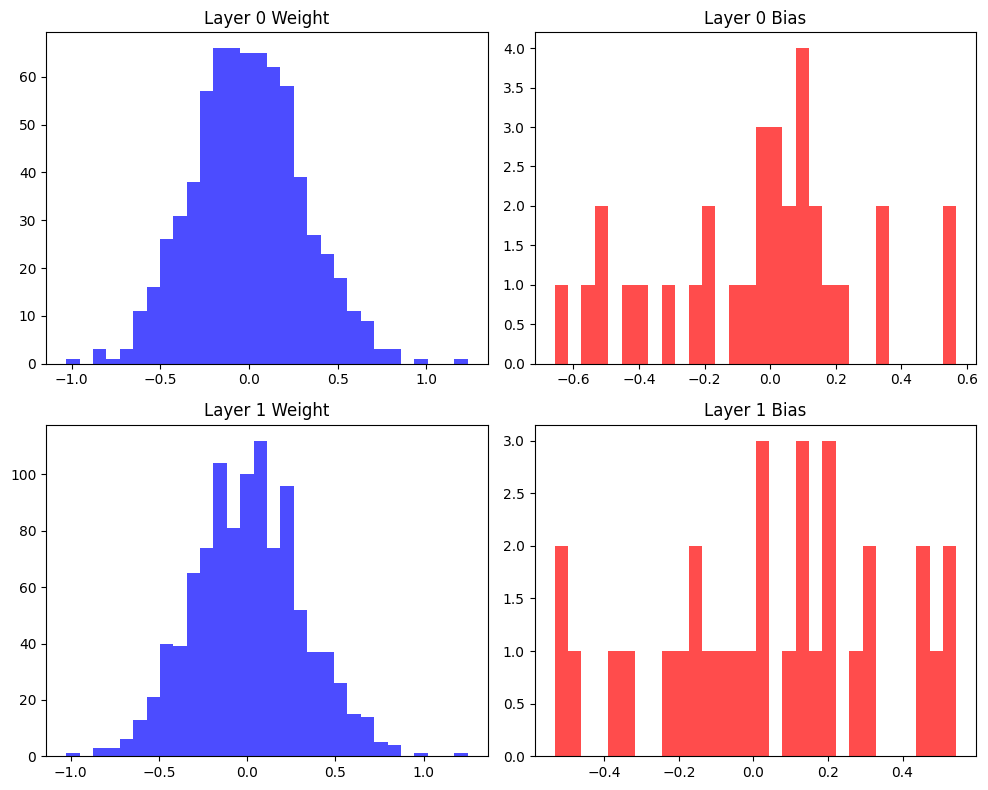

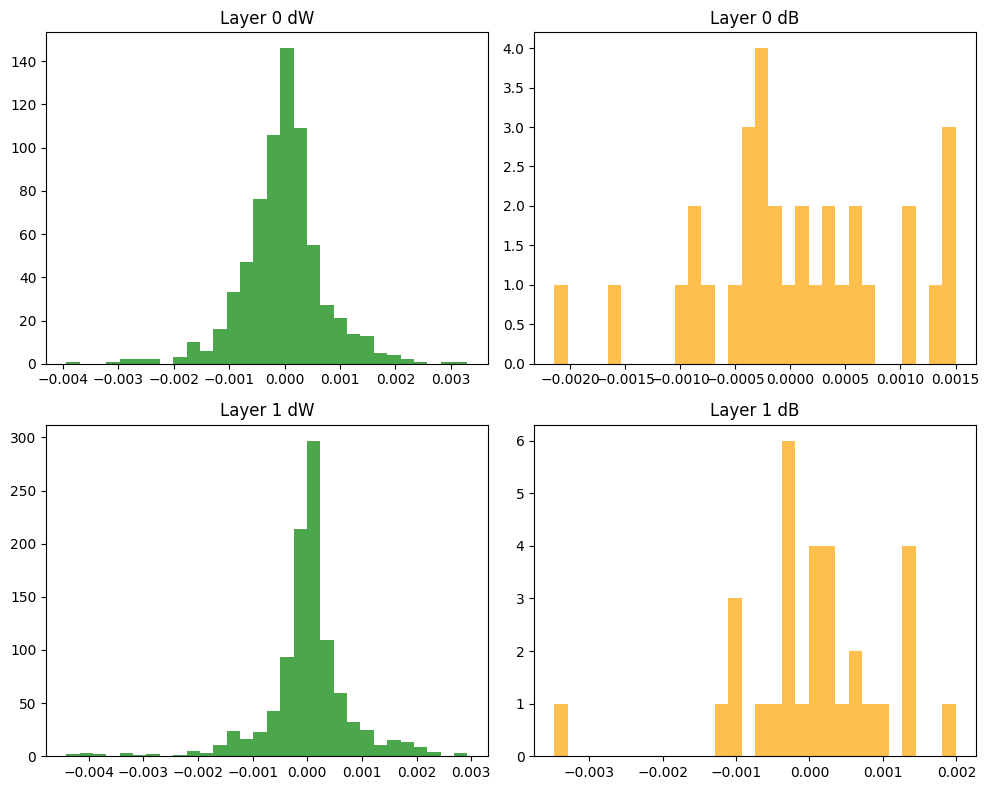


Melatih FFNN: L1 Regularisasi (0.001)
Epoch 1/20 [==============================] 100% - loss: 1.2039 - val_loss: 1.0307
Epoch 2/20 [==============================] 100% - loss: 0.9674 - val_loss: 0.8867
Epoch 3/20 [==============================] 100% - loss: 0.8639 - val_loss: 0.8179
Epoch 4/20 [==============================] 100% - loss: 0.8098 - val_loss: 0.7768
Epoch 5/20 [==============================] 100% - loss: 0.7749 - val_loss: 0.7474
Epoch 6/20 [==============================] 100% - loss: 0.7488 - val_loss: 0.7242
Epoch 7/20 [==============================] 100% - loss: 0.7277 - val_loss: 0.7049
Epoch 8/20 [==============================] 100% - loss: 0.7101 - val_loss: 0.6889
Epoch 9/20 [==============================] 100% - loss: 0.6954 - val_loss: 0.6753
Epoch 10/20 [==============================] 100% - loss: 0.6829 - val_loss: 0.6636
Epoch 11/20 [==============================] 100% - loss: 0.6719 - val_loss: 0.6533
Epoch 12/20 [==============================] 1

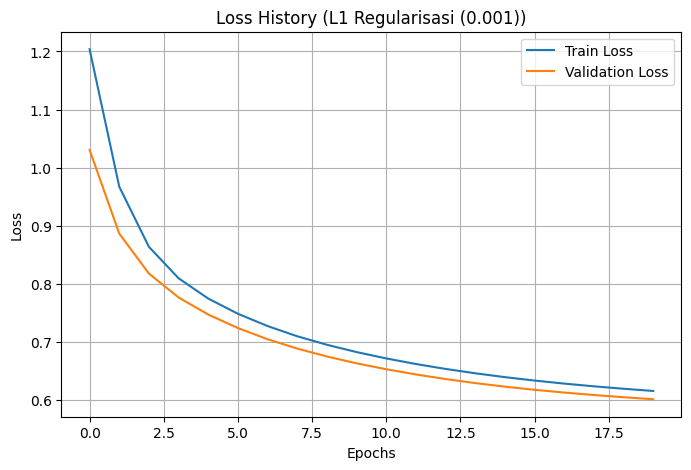

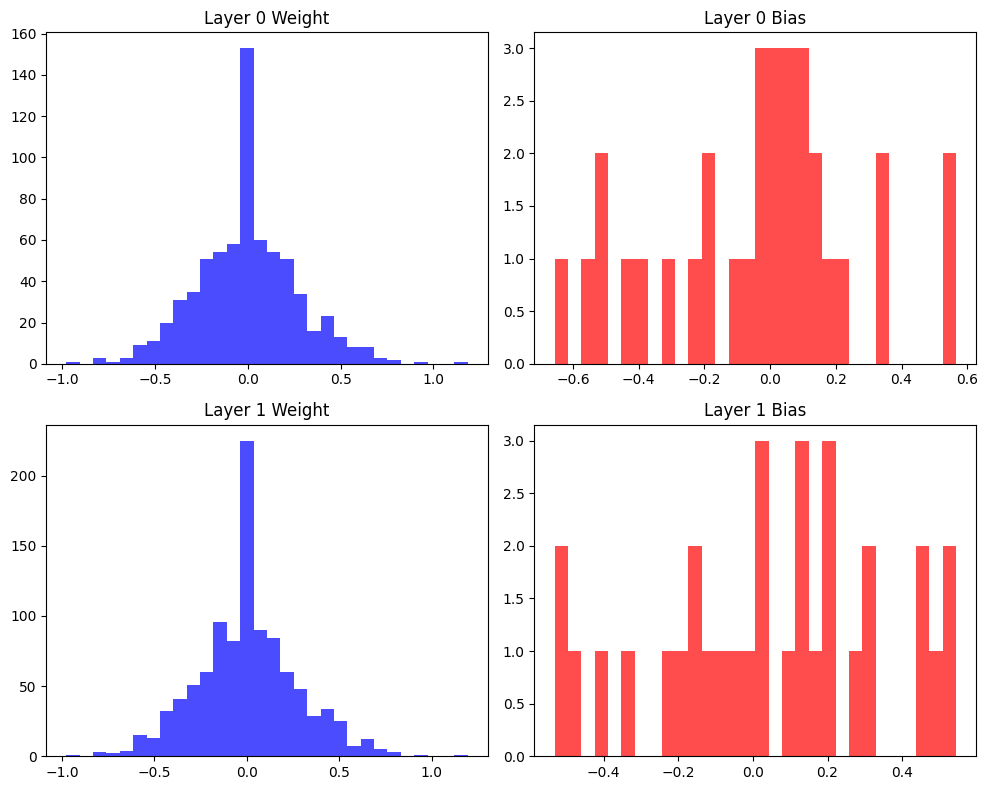

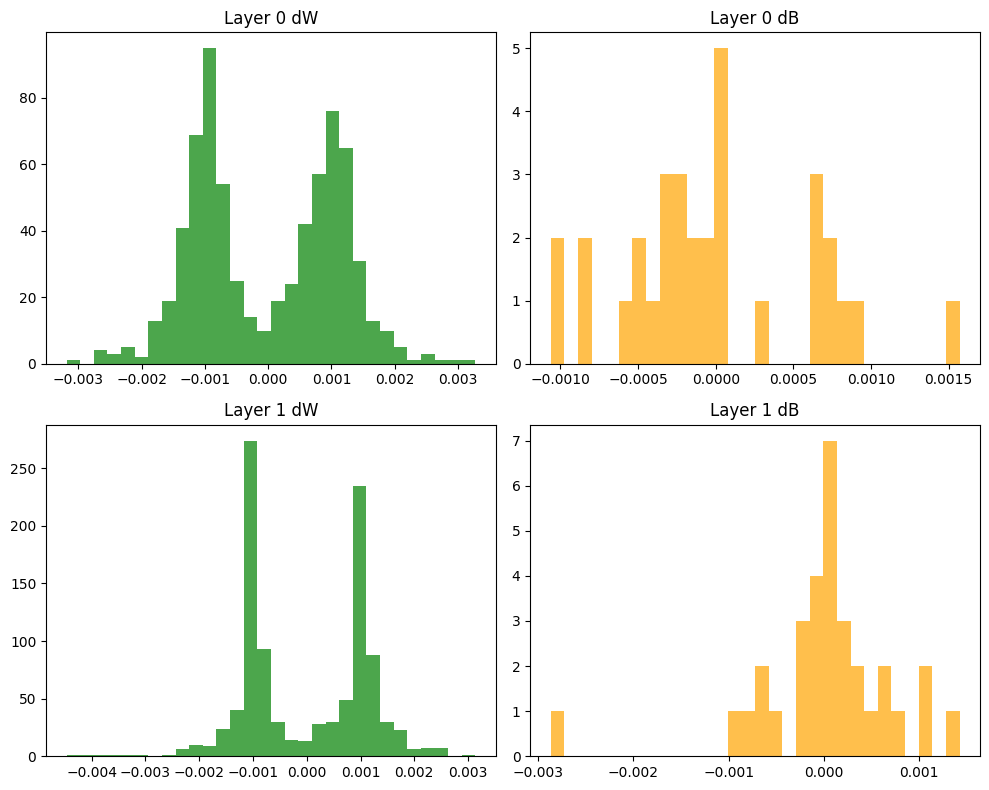


Melatih FFNN: L2 Regularisasi (0.001)
Epoch 1/20 [==============================] 100% - loss: 1.2063 - val_loss: 1.0348
Epoch 2/20 [==============================] 100% - loss: 0.9714 - val_loss: 0.8913
Epoch 3/20 [==============================] 100% - loss: 0.8680 - val_loss: 0.8226
Epoch 4/20 [==============================] 100% - loss: 0.8138 - val_loss: 0.7816
Epoch 5/20 [==============================] 100% - loss: 0.7787 - val_loss: 0.7522
Epoch 6/20 [==============================] 100% - loss: 0.7523 - val_loss: 0.7289
Epoch 7/20 [==============================] 100% - loss: 0.7311 - val_loss: 0.7095
Epoch 8/20 [==============================] 100% - loss: 0.7133 - val_loss: 0.6931
Epoch 9/20 [==============================] 100% - loss: 0.6981 - val_loss: 0.6790
Epoch 10/20 [==============================] 100% - loss: 0.6850 - val_loss: 0.6669
Epoch 11/20 [==============================] 100% - loss: 0.6736 - val_loss: 0.6563
Epoch 12/20 [==============================] 1

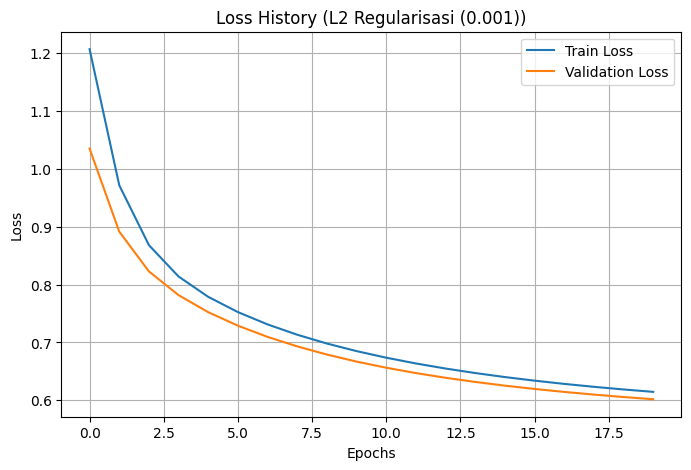

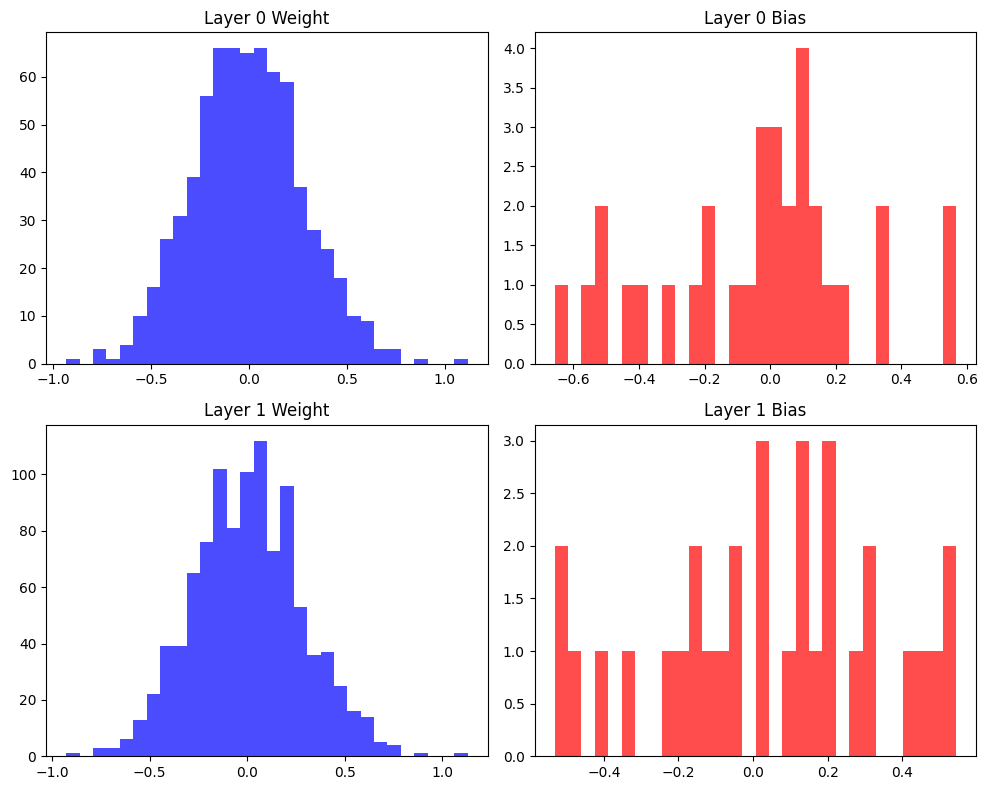

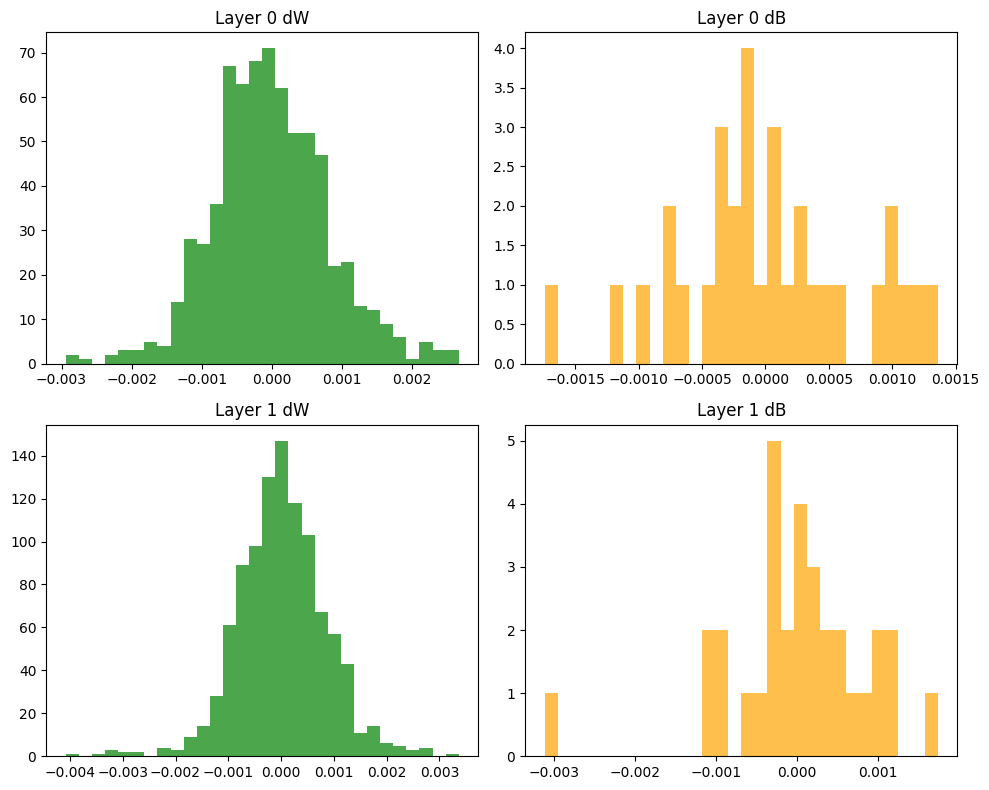

In [34]:
regs = {
    "Tanpa Regularisasi": (0.0, 0.0),
    "L1 Regularisasi (0.001)": (0.001, 0.0),
    "L2 Regularisasi (0.001)": (0.0, 0.001)
}

history_reg = {}
model_reg = {}

for name, (l1, l2) in regs.items():
    print(f"\nMelatih FFNN: {name}")
    model = FFNN(loss=BCE(), layers=[input_dim, 32, 32, output_dim], activation=[ReLU(), ReLU(), Sigmoid()], link_verbose=False, init_method='normal', mean=0, variance=0.1, seed=42)
    hist = model.fit(X_train_scaled, y_train_np, epochs=20, learning_rate=0.01, batch_size=32, verbose=1, X_val=X_val_scaled, y_val=y_val_np, l1=l1, l2=l2)
    
    y_pred_val = model.predict(X_val_scaled)
    acc = calculate_accuracy(y_val_np, y_pred_val)
    print(f"{name} - Val Acc: {acc:.4f}, Final Val Loss: {hist['val_loss'][-1]:.4f}")
    
    history_reg[name] = hist
    model_reg[name] = model
    plot_history(hist, title=f"Loss History ({name})")
    model.show_weight_distribution(layers=[0, 1])
    model.show_dw_distribution(layers=[0, 1])


### 5. Pengaruh Inisialisasi Bobot


Melatih FFNN: Zero Init
Epoch 1/20 [==============================] 100% - loss: 0.6926 - val_loss: 0.6921
Epoch 2/20 [==============================] 100% - loss: 0.6916 - val_loss: 0.6912
Epoch 3/20 [==============================] 100% - loss: 0.6906 - val_loss: 0.6903
Epoch 4/20 [==============================] 100% - loss: 0.6897 - val_loss: 0.6894
Epoch 5/20 [==============================] 100% - loss: 0.6888 - val_loss: 0.6885
Epoch 6/20 [==============================] 100% - loss: 0.6879 - val_loss: 0.6877
Epoch 7/20 [==============================] 100% - loss: 0.6871 - val_loss: 0.6869
Epoch 8/20 [==============================] 100% - loss: 0.6863 - val_loss: 0.6862
Epoch 9/20 [==============================] 100% - loss: 0.6855 - val_loss: 0.6854
Epoch 10/20 [==============================] 100% - loss: 0.6848 - val_loss: 0.6847
Epoch 11/20 [==============================] 100% - loss: 0.6841 - val_loss: 0.6841
Epoch 12/20 [==============================] 100% - loss: 0.

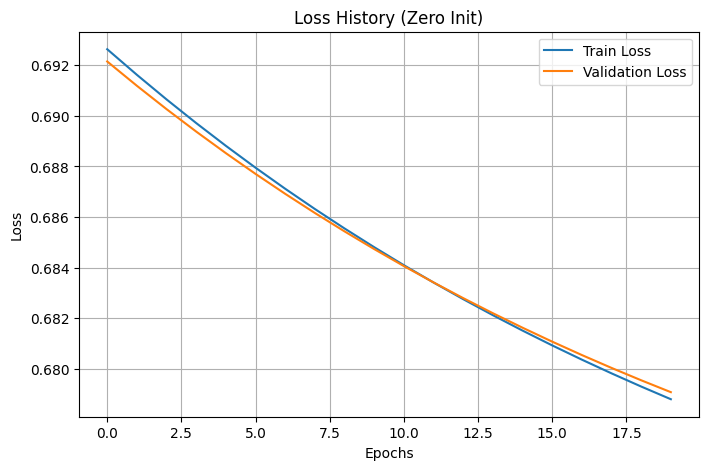

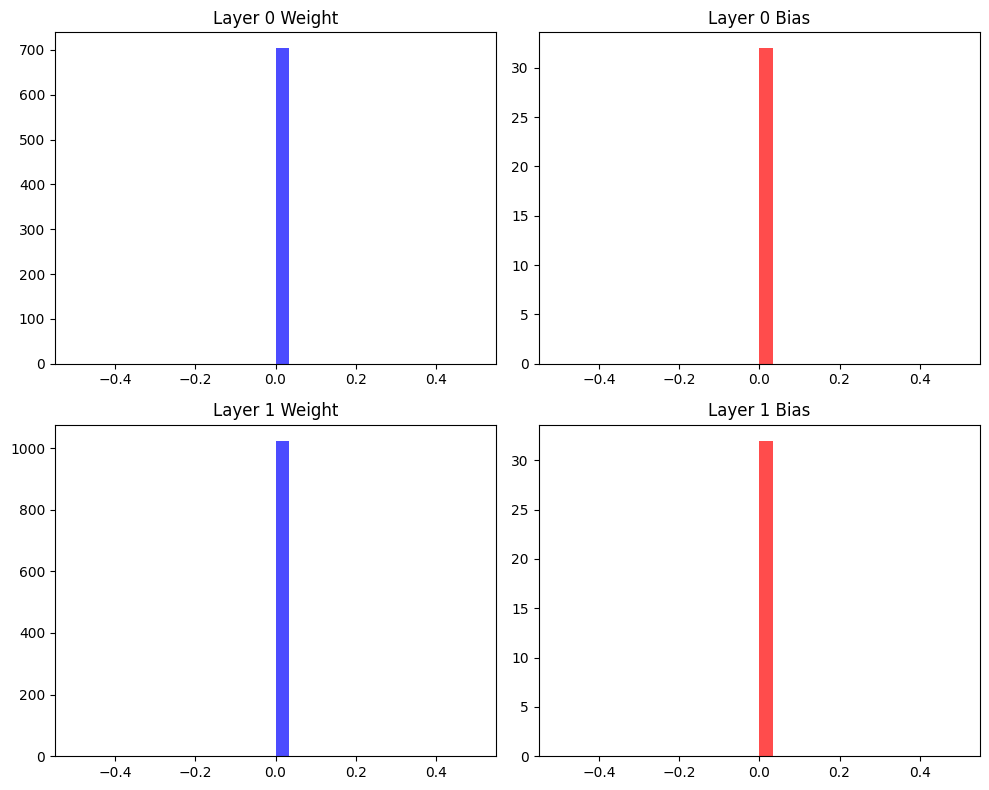

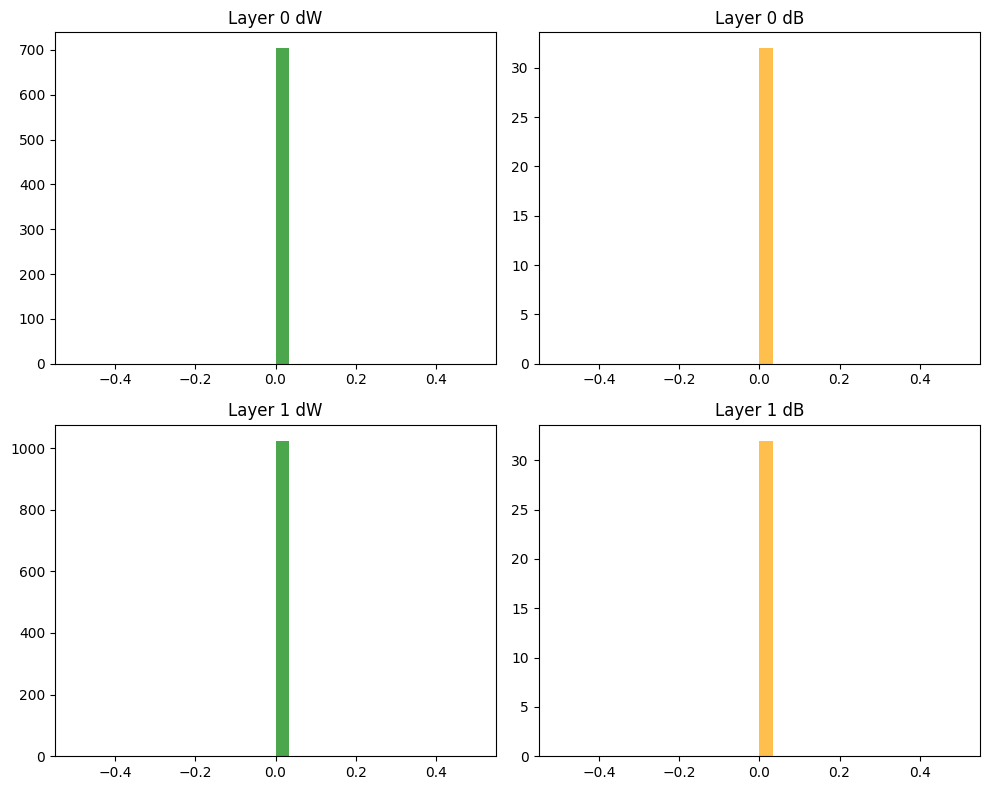


Melatih FFNN: Uniform Init (-0.5, 0.5)
Epoch 1/20 [==============================] 100% - loss: 0.9661 - val_loss: 0.8877
Epoch 2/20 [==============================] 100% - loss: 0.8720 - val_loss: 0.8308
Epoch 3/20 [==============================] 100% - loss: 0.8323 - val_loss: 0.8002
Epoch 4/20 [==============================] 100% - loss: 0.8065 - val_loss: 0.7775
Epoch 5/20 [==============================] 100% - loss: 0.7857 - val_loss: 0.7583
Epoch 6/20 [==============================] 100% - loss: 0.7675 - val_loss: 0.7414
Epoch 7/20 [==============================] 100% - loss: 0.7513 - val_loss: 0.7264
Epoch 8/20 [==============================] 100% - loss: 0.7369 - val_loss: 0.7129
Epoch 9/20 [==============================] 100% - loss: 0.7238 - val_loss: 0.7007
Epoch 10/20 [==============================] 100% - loss: 0.7120 - val_loss: 0.6897
Epoch 11/20 [==============================] 100% - loss: 0.7013 - val_loss: 0.6796
Epoch 12/20 [==============================] 

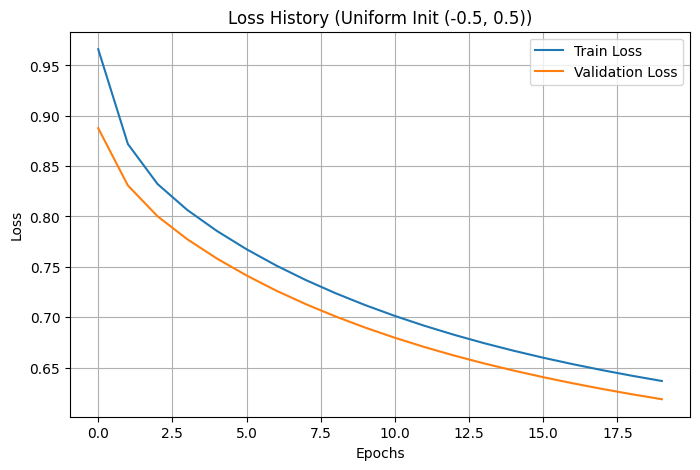

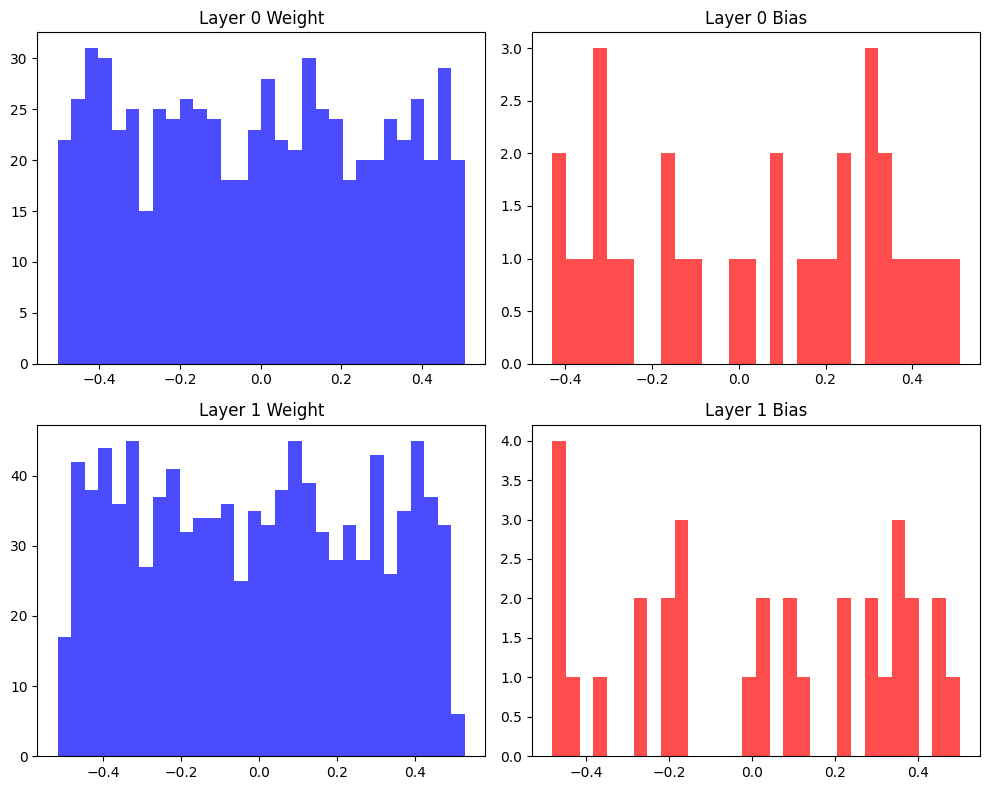

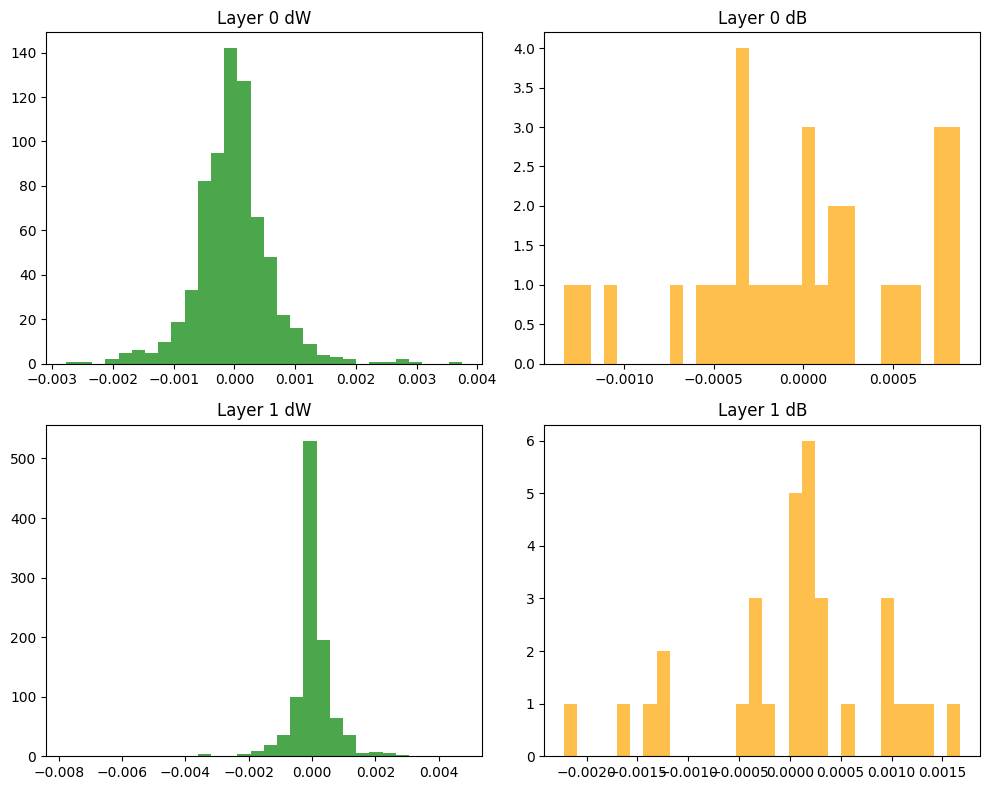


Melatih FFNN: Normal Init (mean=0, var=0.1)
Epoch 1/20 [==============================] 100% - loss: 1.2108 - val_loss: 1.0421
Epoch 2/20 [==============================] 100% - loss: 0.9806 - val_loss: 0.9018
Epoch 3/20 [==============================] 100% - loss: 0.8800 - val_loss: 0.8356
Epoch 4/20 [==============================] 100% - loss: 0.8282 - val_loss: 0.7966
Epoch 5/20 [==============================] 100% - loss: 0.7949 - val_loss: 0.7685
Epoch 6/20 [==============================] 100% - loss: 0.7697 - val_loss: 0.7460
Epoch 7/20 [==============================] 100% - loss: 0.7492 - val_loss: 0.7269
Epoch 8/20 [==============================] 100% - loss: 0.7317 - val_loss: 0.7106
Epoch 9/20 [==============================] 100% - loss: 0.7166 - val_loss: 0.6963
Epoch 10/20 [==============================] 100% - loss: 0.7035 - val_loss: 0.6839
Epoch 11/20 [==============================] 100% - loss: 0.6919 - val_loss: 0.6729
Epoch 12/20 [===========================

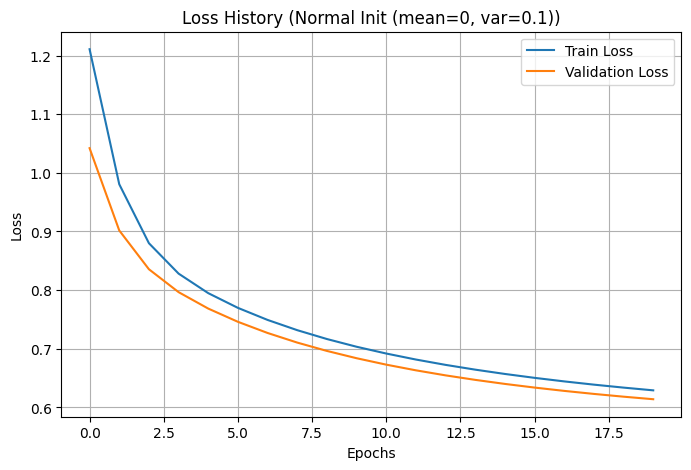

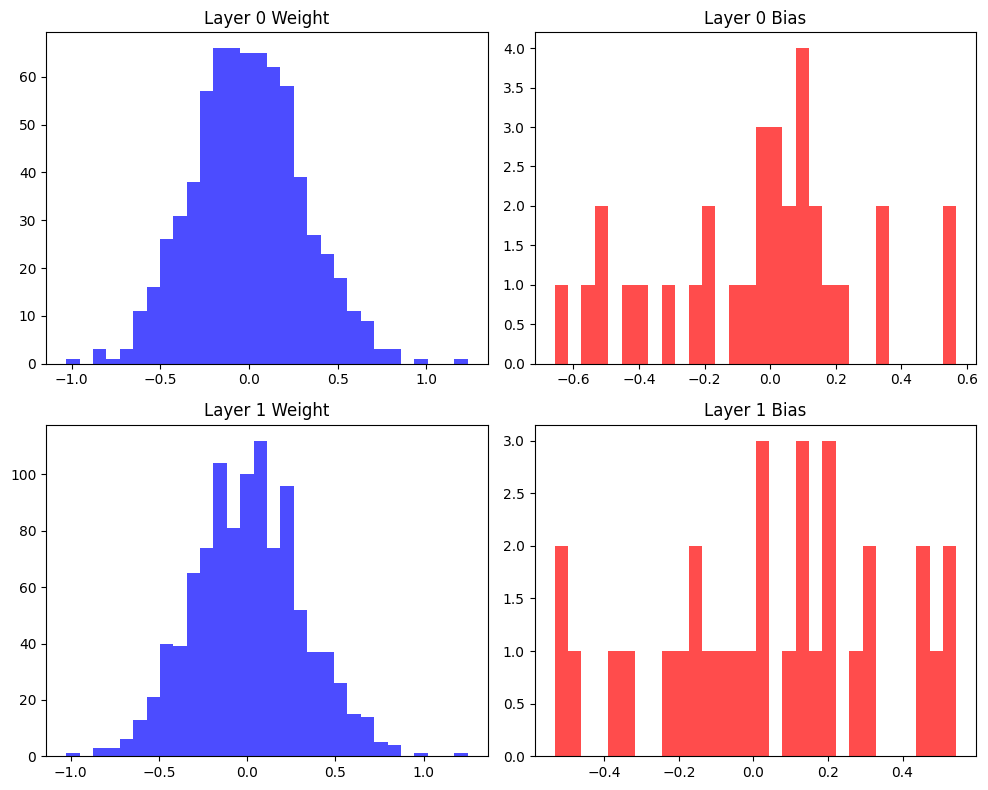

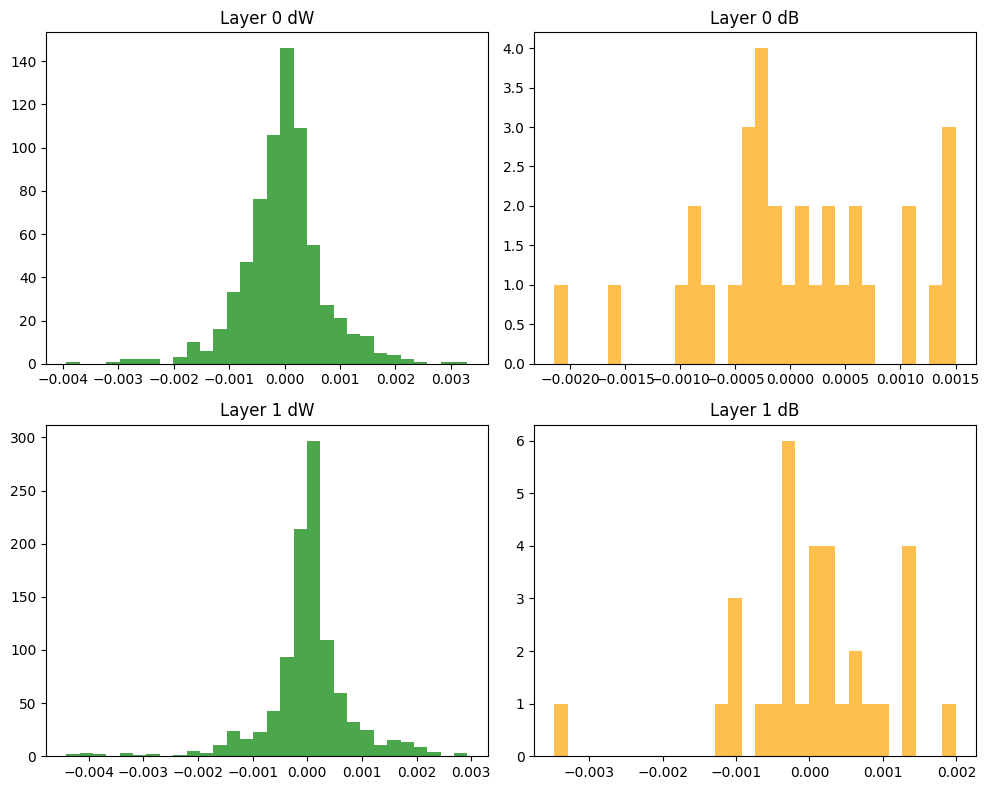

In [35]:
init_methods = {
    "Zero Init": {"init_method": "zero"},
    "Uniform Init (-0.5, 0.5)": {"init_method": "uniform", "lower": -0.5, "upper": 0.5, "seed": 42},
    "Normal Init (mean=0, var=0.1)": {"init_method": "normal", "mean": 0, "variance": 0.1, "seed": 42}
}

history_init = {}
model_init = {}

for name, kwargs in init_methods.items():
    print(f"\nMelatih FFNN: {name}")
    model = FFNN(loss=BCE(), layers=[input_dim, 32, 32, output_dim], activation=[ReLU(), ReLU(), Sigmoid()], link_verbose=False, **kwargs)
    hist = model.fit(X_train_scaled, y_train_np, epochs=20, learning_rate=0.01, batch_size=32, verbose=1, X_val=X_val_scaled, y_val=y_val_np)
    
    y_pred_val = model.predict(X_val_scaled)
    acc = calculate_accuracy(y_val_np, y_pred_val)
    print(f"{name} - Val Acc: {acc:.4f}, Final Val Loss: {hist['val_loss'][-1]:.4f}")
    
    history_init[name] = hist
    model_init[name] = model
    plot_history(hist, title=f"Loss History ({name})")
    model.show_weight_distribution(layers=[0, 1])
    model.show_dw_distribution(layers=[0, 1])


### 6. Uji Perbandingan
Membandingkan model FFNN manual dengan library sklearn MLPClassifier.

In [ ]:
print("\n--UJI PERBANDINGAN--")

# Model FFNN Manual
model_manual = FFNN(loss=BCE(), layers=[input_dim, 32, 32, output_dim], activation=[ReLU(), ReLU(), Sigmoid()], link_verbose=False, init_method='normal', mean=0, variance=0.1, seed=42)
model_manual.fit(X_train_scaled, y_train_np, epochs=20, learning_rate=0.01, batch_size=32, verbose=1, X_val=X_val_scaled, y_val=y_val_np)
y_pred_manual = model_manual.predict(X_val_scaled)
acc_manual = calculate_accuracy(y_val_np, y_pred_manual)
print(f"Akurasi FFNN Manual (Test set/Validation): {acc_manual:.4f}")

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# Model Sklearn MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(32, 32), activation='relu', solver='sgd', learning_rate_init=0.01, batch_size=32, max_iter=20, random_state=42)
mlp.fit(X_train_scaled, y_train)
acc_sklearn = mlp.score(X_val_scaled, y_val)
print(f"Akurasi sklearn MLPClassifier (Test set/Validation): {acc_sklearn:.4f}")



-- UJI PERBANDINGAN --
Epoch 1/20 [==============================] 100% - loss: 1.2108 - val_loss: 1.0421
Epoch 2/20 [==============================] 100% - loss: 0.9806 - val_loss: 0.9018
Epoch 3/20 [==============================] 100% - loss: 0.8800 - val_loss: 0.8356
Epoch 4/20 [==============================] 100% - loss: 0.8282 - val_loss: 0.7966
Epoch 5/20 [==============================] 100% - loss: 0.7949 - val_loss: 0.7685
Epoch 6/20 [==============================] 100% - loss: 0.7697 - val_loss: 0.7460
Epoch 7/20 [==============================] 100% - loss: 0.7492 - val_loss: 0.7269
Epoch 8/20 [==============================] 100% - loss: 0.7317 - val_loss: 0.7106
Epoch 9/20 [==============================] 100% - loss: 0.7166 - val_loss: 0.6963
Epoch 10/20 [==============================] 100% - loss: 0.7035 - val_loss: 0.6839
Epoch 11/20 [==============================] 100% - loss: 0.6919 - val_loss: 0.6729
Epoch 12/20 [==============================] 100% - loss: 0.6